# Stage 8C.1 - Full Beam-to-Write Cockpit MVP

This notebook is an optical/energy/exposure cockpit. It does not predict material modification.

The purpose is to tune the editable source-to-sample lab chain, inspect real optical-field fluence diagnostics, and keep exposure bookkeeping visible while future material-response modules remain intentionally disabled.

## Notebook roadmap

Run the cells top to bottom:

1. **Set controls** - edit the single user-control cell below.
2. **Run the lab realism report** - stage-by-stage source-to-sample status.
3. **Acquire the real optical field** - from the repository engine (fails loudly if unavailable).
4. **Convert to fluence** - energy-scaled optical fluence (Mode B).
5. **Inspect the dashboard** - header status badge, beam-path strip, warning cards, XY / central ROI / XZ panels.
6. **Inspect the warnings** - captured-power drift, crop-edge peak, and feasibility flags.
7. **Interpret the claim boundary** - optical fluence only; material response is a future stage.

The large **DISPLAY TRUST** badge (PASS / CAUTION / FAIL) tells you at a glance whether the current optical/fluence display can be trusted.


In [1]:
# ============================================================
# FULL BEAM-TO-WRITE COCKPIT MVP - USER CONTROLS
# ============================================================

planning_mode = True
save_outputs = False
figure_dpi = 180
show_caveats = True
show_warnings = True
show_diagnostic_panels = True

# --- Simulation quality ---
engine_preset = "fast"          # fast | balanced | publication
engine_path = "ideal"           # ideal | realistic
require_real_field = True
allow_synthetic_demo_field = False

# --- Laser source ---
wavelength_nm = 1030.0
pulse_duration_fs = 260.0
repetition_rate_Hz = 25_000.0
pulse_energy_before_optics_uJ = 200.0
average_power_limit_W = 10.0
beam_radius_mm = 2.0
polarisation_state = "linear"

# --- Pre-SLM beam conditioning ---
pre_slm_transmission = 1.0
input_beam_radius_mm = 2.0
beam_ellipticity = 1.0
pointing_offset_x_um = 0.0
pointing_offset_y_um = 0.0
aperture_radius_mm = None

# --- Telescope / beam expander ---
telescope_enabled = False
telescope_magnification = 1.0
telescope_transmission = 1.0

# --- SLM1 phase / vortex ---
slm1_enabled = True
phase_profile = "vortex"
ell = 3
phase_quantisation_levels = 256
slm_pixel_pitch_um = 8.0
slm_active_width_px = None
slm_active_height_px = None
slm1_diffraction_efficiency = 0.95

# --- SLM2 / phase correction / holography ---
generation_method = "holographic"    # holographic | physical
target_core_diameter_um = 3.0
target_bessel_length_um = 150.0
axicon_k_r = None
blaze_period_px = 20
slm2_diffraction_efficiency = 0.95
slm2_conjugate_mode = "preserve_vortex"
physical_axicon_enabled = False
physical_axicon_angle_deg = None

# --- First-order filtering ---
first_order_filter_enabled = True
selected_first_order_fraction = 0.73
filter_radius_px_or_lpmm = None
zero_order_leakage_fraction = 0.0

# --- Relay optics ---
relay_transmission = 0.90
relay_magnification = 1.0
relay_aberration_enabled = False

# --- Objective and pupil ---
objective_NA = 0.45
objective_transmission = 0.85
objective_effective_focal_length_mm = None
objective_pupil_diameter_mm = None
pupil_diameter_override_mm = None

# --- Sample/interface ---
material_name = "Cr:ZnSe"
refractive_index = 2.44
sample_thickness_mm = 5.0
focus_depth_um = 100.0
sample_interface_transmission = 0.95
use_fresnel_interface_estimate = False
surface_tilt_mrad = 0.0

# --- In-sample propagation / field stack ---
grid_N = None
device_downsample = None
axial_planes = None
crop_window_um = None

# --- Field/fluence display ---
selected_z_um = "target_depth"       # target_depth | optical_peak | sample_surface | custom
selected_z_mode = selected_z_um
custom_z_um = 100.0
central_roi_half_width_um = 10.0
display_scaling = "percentile"       # linear | log | percentile
display_percentile_clip = (0.5, 99.5)
fluence_normalisation_mode = "per_plane_transverse_energy"

# --- Writing plan / exposure bookkeeping ---
writing_mode = "line_x"              # static_single | static_multi | line_x | line_y | line_z | tilted_line | disabled
scan_axis = "x"
scan_speed_mm_s = 1.0
line_length_um = 500.0
effective_diameter_um = 3.0
num_static_pulses = 100
num_passes = 1
z_step_um = 0.0
tilt_angle_deg = 0.0

# --- Future physics toggles: must remain disabled in Stage 8C.1 ---
enable_material_response = False
enable_threshold_proxy = False
enable_dose_accumulation = False
enable_nonlinear_proxy = False
enable_thermal_proxy = False
enable_microscope_proxy = False
enable_calibrated_prediction = False


# --- Stage 8C.3 active lab-realism overrides ---
# These values are copied into controls after default_lab_controls(); edit them
# to perturb the diagnostic optical field while keeping material response disabled.
active_lab_realism_overrides = {
    "enable_beam_decentre": False,
    "beam_decentre_x_um": 0.0,
    "beam_decentre_y_um": 0.0,
    "enable_beam_tilt": False,
    "beam_tilt_x_mrad": 0.0,
    "beam_tilt_y_mrad": 0.0,
    "enable_beam_ellipticity": False,
    "beam_radius_x_um": 24.0,
    "beam_radius_y_um": 24.0,
    "beam_rotation_deg": 0.0,
    "enable_input_aperture": False,
    "input_aperture_radius_um": 24.0,
    "input_aperture_decentre_x_um": 0.0,
    "input_aperture_decentre_y_um": 0.0,
    "enable_slm_phase_centre_offset": False,
    "slm_phase_centre_offset_x_um": 0.0,
    "slm_phase_centre_offset_y_um": 0.0,
    "enable_vortex_centre_offset": False,
    "vortex_centre_offset_x_um": 0.0,
    "vortex_centre_offset_y_um": 0.0,
    "enable_axicon_centre_offset": False,
    "axicon_centre_offset_x_um": 0.0,
    "axicon_centre_offset_y_um": 0.0,
    "enable_physical_axicon_misalignment": False,
    "physical_axicon_apex_offset_x_um": 0.0,
    "physical_axicon_apex_offset_y_um": 0.0,
    "physical_axicon_tilt_x_mrad": 0.0,
    "physical_axicon_tilt_y_mrad": 0.0,
    "physical_axicon_angle_error_deg": 0.0,
    "enable_axicon_apex_defect": False,
    "axicon_apex_defect_radius_um": 0.0,
    "enable_slm_phase_quantisation": False,
    "slm_phase_levels": 256,
    "enable_slm_pixelation": False,
    "enable_slm_fill_factor": False,
    "slm_fill_factor": 1.0,
    "enable_slm_dead_pixels": False,
    "dead_pixel_fraction": 0.0,
    "dead_pixel_seed": 7,
    "enable_slm_phase_noise": False,
    "slm_phase_noise_rms_rad": 0.0,
    "slm_phase_noise_seed": 11,
    "enable_slm_active_area": False,
    "slm_active_width_um": 50.0,
    "slm_active_height_um": 50.0,
    "slm_active_area_decentre_x_um": 0.0,
    "slm_active_area_decentre_y_um": 0.0,
    "enable_slm_rotation": False,
    "slm_rotation_deg": 0.0,
    "enable_mask_rotation": False,
    "phase_mask_rotation_deg": 0.0,
    "enable_zero_order_leakage": False,
    "zero_order_mode": "central_gaussian",
    "enable_unwanted_order_leakage": False,
    "unwanted_order_fraction": 0.0,
    "unwanted_order_kx_shift": 0.0,
    "unwanted_order_ky_shift": 0.0,
    "enable_first_order_filter": False,
    "first_order_filter_radius_px": None,
    "enable_first_order_filter_decentre": False,
    "first_order_filter_decentre_x_px": 0.0,
    "first_order_filter_decentre_y_px": 0.0,
    "enable_first_order_filter_clipping": False,
    "first_order_filter_clipping_fraction_override": None,
    "enable_relay_magnification_error": False,
    "relay_magnification_error_fraction": 0.0,
    "enable_relay_decentre": False,
    "relay_decentre_x_um": 0.0,
    "relay_decentre_y_um": 0.0,
    "enable_relay_tilt": False,
    "relay_tilt_x_mrad": 0.0,
    "relay_tilt_y_mrad": 0.0,
    "enable_relay_aperture": False,
    "relay_aperture_radius_um": 30.0,
    "relay_aperture_decentre_x_um": 0.0,
    "relay_aperture_decentre_y_um": 0.0,
    "enable_pupil_clipping": False,
    "pupil_radius_um": 20.0,
    "pupil_decentre_x_um": 0.0,
    "pupil_decentre_y_um": 0.0,
    "pupil_fill_target_fraction": 0.8,
    "enable_zernike_aberrations": False,
    "zernike_defocus_waves": 0.0,
    "zernike_astig_0_waves": 0.0,
    "zernike_astig_45_waves": 0.0,
    "zernike_coma_x_waves": 0.0,
    "zernike_coma_y_waves": 0.0,
    "zernike_spherical_waves": 0.0,
    "zernike_trefoil_x_waves": 0.0,
    "zernike_trefoil_y_waves": 0.0,
    "enable_defocus": False,
    "focus_offset_um": 0.0,
    "enable_focus_depth_error": False,
    "focus_depth_error_um": 0.0,
    "enable_sample_tilt": False,
    "sample_tilt_x_mrad": 0.0,
    "sample_tilt_y_mrad": 0.0,
    "enable_surface_offset": False,
    "sample_surface_z_um": 0.0,
    "enable_refractive_index_error": False,
    "refractive_index_error": 0.0,
    "enable_sample_thickness_limit": False,
    "enable_interface_reflection": False,
    "enable_pulse_energy_jitter": False,
    "pulse_energy_jitter_rms_fraction": 0.0,
    "pulse_energy_jitter_seed": 23,
    "enable_repetition_rate_error": False,
    "repetition_rate_error_fraction": 0.0,
    "enable_pulse_duration_error": False,
    "pulse_duration_error_fraction": 0.0,
    "enable_average_power_limit": True,
    "enable_pointing_jitter": False,
    "pointing_jitter_rms_urad": 0.0,
    "pointing_jitter_seed": 31,
    "enable_stage_position_jitter": False,
    "stage_jitter_x_um": 0.0,
    "stage_jitter_y_um": 0.0,
    "stage_jitter_z_um": 0.0,
    "stage_jitter_seed": 37,
    "enable_focus_drift": False,
    "focus_drift_um_per_min": 0.0,
    "enable_camera_crop": False,
    "camera_crop_width_um": 20.0,
    "camera_crop_height_um": 20.0,
    "camera_crop_centre_x_um": 0.0,
    "camera_crop_centre_y_um": 0.0,
    "enable_detector_noise": False,
    "detector_noise_fraction": 0.0,
    "detector_noise_seed": 41,
    "enable_display_autoscale": True,
    "display_autoscale": True,
}


## 1. Purpose and claim boundary

This notebook is an optical/energy/exposure cockpit. It does not predict material modification. It scales real optical-field intensity arrays to optical fluence, reports energy throughput, and performs exposure bookkeeping only.

In [2]:
# Guard rails for saving, demo fields, and future physics toggles.
if save_outputs and not show_caveats:
    raise ValueError("Cannot save Stage 8C.1 outputs with show_caveats=False.")

future_flags = {
    "enable_material_response": enable_material_response,
    "enable_threshold_proxy": enable_threshold_proxy,
    "enable_dose_accumulation": enable_dose_accumulation,
    "enable_nonlinear_proxy": enable_nonlinear_proxy,
    "enable_thermal_proxy": enable_thermal_proxy,
    "enable_microscope_proxy": enable_microscope_proxy,
    "enable_calibrated_prediction": enable_calibrated_prediction,
}
if any(future_flags.values()):
    enabled = [name for name, value in future_flags.items() if value]
    raise NotImplementedError(f"Stage 8C.1 does not implement future physics toggles: {enabled}")
if allow_synthetic_demo_field and save_outputs:
    raise ValueError("unit_test_or_demo_only fields cannot be saved as governed outputs.")

CAVEAT_TEXT = (
    "This is an optical/energy/exposure cockpit. It does not model absorption, "
    "material modification, ablation, cracks, voids, waveguides, nonlinear propagation, "
    "or thermal accumulation. Energy-scaled fluence is optical fluence only."
)
if show_caveats:
    print(CAVEAT_TEXT)


This is an optical/energy/exposure cockpit. It does not model absorption, material modification, ablation, cracks, voids, waveguides, nonlinear propagation, or thermal accumulation. Energy-scaled fluence is optical fluence only.


In [3]:
# ============================================================
# RUNTIME CHECK + AUTORELOAD + INLINE BACKEND
# Prevents two failure modes:
#   1. stale import / wrong path -> notebook renders the OLD dashboard
#   2. matplotlib.use("Agg") in the modules -> display(fig) shows NO image inline
# ============================================================
import os
import sys
import inspect
from pathlib import Path

# Enable autoreload so edits to vbb_study are picked up without a manual kernel restart.
try:
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("load_ext", "autoreload")
        _ip.run_line_magic("autoreload", "2")
except Exception:
    pass

# Make sure the local Publication_Study package wins on sys.path.
for _cand in [Path.cwd(), *Path.cwd().parents]:
    if (_cand / "bessel_twin_core.py").is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break

# Import the digital-twin modules first. They call matplotlib.use("Agg") at import,
# so we re-enable the inline backend AFTERWARDS to guarantee figures render in-notebook.
import vbb_study
import vbb_study.digital_twin.cockpit_dashboard as cd
try:
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("Python    :", sys.executable)
print("CWD       :", os.getcwd())
print("vbb_study :", Path(vbb_study.__file__).resolve())
print("cockpit   :", Path(cd.__file__).resolve())
print("has compute_overall_status :", hasattr(cd, "compute_overall_status"))
print("has build_beam_path_strip  :", hasattr(cd, "build_beam_path_strip"))
print("dashboard is Stage 8C.2    :", "DISPLAY TRUST" in inspect.getsource(cd))

# Fail loudly if a stale module is loaded so we never silently render the old dashboard.
assert hasattr(cd, "compute_overall_status"), "Stale cockpit_dashboard import - restart the kernel."
assert "DISPLAY TRUST" in inspect.getsource(cd), "Old dashboard loaded - restart kernel / check path."

Python    : C:\PhD\.venv2\Scripts\python.exe
CWD       : C:\PhD\Code\Publication_Study\notebooks\digital_twin
vbb_study : C:\PhD\Code\Publication_Study\vbb_study\__init__.py
cockpit   : C:\PhD\Code\Publication_Study\vbb_study\digital_twin\cockpit_dashboard.py
has compute_overall_status : True
has build_beam_path_strip  : True
dashboard is Stage 8C.2    : True


In [4]:
from pathlib import Path
import sys
import numpy as np

_root = Path.cwd()
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "bessel_twin_core.py").is_file():
        _root = _candidate
        break
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from vbb_study.digital_twin.field_coupling import (
    MissingOpticalFieldError,
    extract_plane_from_surfacefield,
    extract_stack_from_surfacefield,
    plane_from_arrays,
)
from vbb_study.digital_twin.field_fluence import scale_plane_to_fluence, scale_stack_to_fluence
from vbb_study.digital_twin.lab_perturbations import (
    apply_lab_perturbations_to_stack,
    classification_rows_for_controls,
    physical_placement_rows_for_controls,
)
from vbb_study.digital_twin.active_realism_metrics import (
    build_stage8c3_sensitivity_scenarios,
    compute_misalignment_sensitivity_sweep,
    compute_degradation_metrics,
    metric_delta_table,
    plot_baseline_vs_perturbed_comparison,
    plot_misalignment_sensitivity_sweep,
)
from vbb_study.digital_twin.lab_realism_controls import (
    default_lab_controls,
    build_energy_ledger_from_controls,
    build_exposure_summary_from_controls,
    build_lab_realism_report,
)
from vbb_study.digital_twin.cockpit_dashboard import (
    compute_peak_location_diagnostics,
    build_warning_flags,
    plot_integrated_cockpit_dashboard,
    make_interpretation_text,
)


## 2. User controls

All editable controls are in the first code cell.

In [5]:
control_names = [
    "planning_mode", "save_outputs", "figure_dpi", "show_caveats", "show_warnings", "show_diagnostic_panels",
    "engine_preset", "engine_path", "require_real_field", "allow_synthetic_demo_field",
    "wavelength_nm", "pulse_duration_fs", "repetition_rate_Hz", "pulse_energy_before_optics_uJ", "average_power_limit_W", "beam_radius_mm", "polarisation_state",
    "pre_slm_transmission", "input_beam_radius_mm", "beam_ellipticity", "pointing_offset_x_um", "pointing_offset_y_um", "aperture_radius_mm",
    "telescope_enabled", "telescope_magnification", "telescope_transmission",
    "slm1_enabled", "phase_profile", "ell", "phase_quantisation_levels", "slm_pixel_pitch_um", "slm_active_width_px", "slm_active_height_px", "slm1_diffraction_efficiency",
    "generation_method", "target_core_diameter_um", "target_bessel_length_um", "axicon_k_r", "blaze_period_px", "slm2_diffraction_efficiency", "slm2_conjugate_mode", "physical_axicon_enabled", "physical_axicon_angle_deg",
    "first_order_filter_enabled", "selected_first_order_fraction", "filter_radius_px_or_lpmm", "zero_order_leakage_fraction",
    "relay_transmission", "relay_magnification", "relay_aberration_enabled",
    "objective_NA", "objective_transmission", "objective_effective_focal_length_mm", "objective_pupil_diameter_mm", "pupil_diameter_override_mm",
    "material_name", "refractive_index", "sample_thickness_mm", "focus_depth_um", "sample_interface_transmission", "use_fresnel_interface_estimate", "surface_tilt_mrad",
    "grid_N", "device_downsample", "axial_planes", "crop_window_um",
    "selected_z_um", "selected_z_mode", "custom_z_um", "central_roi_half_width_um", "display_scaling", "display_percentile_clip", "fluence_normalisation_mode",
    "writing_mode", "scan_axis", "scan_speed_mm_s", "line_length_um", "effective_diameter_um", "num_static_pulses", "num_passes", "z_step_um", "tilt_angle_deg",
    "enable_material_response", "enable_threshold_proxy", "enable_dose_accumulation", "enable_nonlinear_proxy", "enable_thermal_proxy", "enable_microscope_proxy", "enable_calibrated_prediction",
]
controls = default_lab_controls()
controls.update({name: globals()[name] for name in control_names})
controls.update(active_lab_realism_overrides)


## 3. Stage-by-stage lab realism report

The `LabRealismReport` is the central source-to-sample table: every stage reports editable inputs, computed outputs, warnings, missing metrics, and handoff.

In [6]:
ledger = build_energy_ledger_from_controls(controls)
exposure_summary = build_exposure_summary_from_controls(
    controls,
    pulse_energy_at_sample_uJ=ledger.energy_at_sample_uJ,
    repetition_rate_Hz=repetition_rate_Hz,
)
lab_report = build_lab_realism_report(controls, energy_ledger=ledger, exposure_summary=exposure_summary)
lab_report.to_dataframe()


,stage_name,enabled,key_inputs,key_outputs,model_status,status_level,warnings,missing_metrics,control_classifications,affected_outputs,handoff_to_next_stage
0,laser_source,True,wavelength_nm=1030; pulse_duration_fs=260; rep...,average_power_before_optics_W=5; power_limit_s...,energy_accounting_prediction,pass,,,wavelength_nm:metadata_only; pulse_duration_fs...,"metadata, fluence, energy_ledger, exposure_boo...",pulse energy and source metadata to pre-SLM co...
1,pre_slm_beam_conditioning,True,pre_slm_transmission=1; input_beam_radius_mm=2...,energy_after_pre_slm_uJ=200; beam_radius_at_sl...,energy_accounting_prediction,missing,,aperture clipping not available from current e...,pre_slm_transmission:energy_active; input_beam...,"energy_ledger, fluence, metadata, warnings, fi...",conditioned beam radius and energy to telescop...
2,telescope_or_beam_expander,False,telescope_enabled=False; telescope_magnificati...,beam_radius_after_telescope_mm=2; energy_after...,energy_accounting_prediction,diagnostic_only,,,telescope_enabled:geometry_active; telescope_m...,"metadata, warnings, energy_ledger, fluence",beam radius and energy to SLM1
3,slm1_phase,True,slm1_enabled=True; phase_profile=vortex; ell=3...,slm_sampling_status=active area not available ...,optical_prediction,pass,,SLM active area not available from current engine,slm1_enabled:metadata_only; phase_profile:meta...,"metadata, warnings, amplitude, field, fluence,...",vortex/phase state and energy to SLM2 route
4,slm2_phase_or_axicon,True,generation_method=holographic; axicon_k_r=None...,route_status=holographic route; measured_topol...,optical_prediction,pass,,measured topological winding not available fro...,generation_method:metadata_only; axicon_k_r:me...,"metadata, warnings, energy_ledger, fluence, ph...",routed diffracted field to first-order filtering
5,first_order_filter,True,first_order_filter_enabled=True; selected_firs...,carrier_frequency_lpmm=not available from curr...,optical_prediction,pass,,carrier/cone frequency not available from curr...,first_order_filter_enabled:energy_active; sele...,"energy_ledger, warnings, fluence, field, ampli...",selected diffraction order to relay optics
6,relay_optics,True,relay_transmission=0.9; relay_magnification=1;...,energy_after_relay_uJ=computed in energy ledge...,energy_accounting_prediction,pass,,,relay_transmission:energy_active; relay_magnif...,"energy_ledger, fluence, pupil, metadata, warni...",relayed beam to objective pupil
7,objective_and_pupil,True,objective_NA=0.45; objective_transmission=0.85...,pupil_radius_mm=not available from current eng...,optical_prediction,missing,,objective pupil diameter not available from cu...,objective_NA:geometry_active; objective_transm...,"pupil, metadata, warnings, energy_ledger, flue...",focused field to sample interface
8,sample_interface,True,material_name=Cr:ZnSe; refractive_index=2.44; ...,fresnel_normal_incidence_transmission=0.8248; ...,energy_accounting_prediction,pass,,,material_name:geometry_active; refractive_inde...,"sample_geometry, energy_ledger, warnings, flue...",sample-entered optical field to propagation stack
9,in_sample_propagation,True,engine_preset=fast; engine_path=ideal; grid_N=...,field_source_status=not available from current...,optical_prediction,fail,real field is required by controls,real optical field summary not available from ...,engine_preset:diagnostic_active; engine_path:d...,"field, warnings, metadata",real optical intensity stack to fluence scaling


## Active Lab-Realism Controls

Every editable control is classified as `energy_active`, `geometry_active`, `diagnostic_active`, `warning_only`, `metadata_only`, or `future_not_implemented`, with declared affected outputs, implementation status, physical placement, and actual Stage 8C.3 implementation stage. `physics_active` remains a reserved class for future engine-level pre-propagation coupling, but this post-engine diagnostic layer does not use it for stack/image transforms.

In the current scalar optical model, direct Poynting-vector editing is not a primitive active input. Beam direction changes are represented by input beam tilt / angular-spectrum phase ramp. Polarisation and true vectorial energy-flow effects require a vector engine and are metadata-only unless the vector path is active.

The physical-placement audit distinguishes where a perturbation belongs optically from how Stage 8C.3 applies it today. A control can belong at the input field, SLM phase-mask, SLM amplitude/active-area, Fourier plane, relay plane, or objective pupil plane while still being marked `post-propagation diagnostic only` in this MVP.


In [7]:
active_control_columns = [
    "control",
    "value",
    "enabled",
    "classification",
    "affects",
    "implemented",
    "downstream_response_expected",
    "physical_placement",
    "implementation_stage",
    "placement_note",
]
active_control_rows = classification_rows_for_controls(controls)
try:
    import pandas as pd
    active_control_table = pd.DataFrame(active_control_rows)[active_control_columns]
    display(active_control_table)
except Exception:
    active_control_table = active_control_rows
    display(active_control_table)


,control,value,enabled,classification,affects,implemented,downstream_response_expected,physical_placement,implementation_stage,placement_note
0,planning_mode,True,True,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
1,save_outputs,False,False,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
2,figure_dpi,180,True,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
3,show_caveats,True,True,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
4,show_warnings,True,True,metadata_only,metadata,True,changes notebook/report behaviour only,metadata/report only,metadata/report only,recorded for traceability or notebook/report b...
...,...,...,...,...,...,...,...,...,...,...
215,enable_detector_noise,False,False,diagnostic_active,metadata,True,display/diagnostic only; physical metrics unch...,post-propagation diagnostic only,post-propagation diagnostic only,detector noise is a display/diagnostic operation
216,detector_noise_fraction,0.0,False,diagnostic_active,metadata,True,display/diagnostic only; physical metrics unch...,post-propagation diagnostic only,post-propagation diagnostic only,detector noise is a display/diagnostic operation
217,detector_noise_seed,41,False,diagnostic_active,metadata,True,display/diagnostic only; physical metrics unch...,post-propagation diagnostic only,post-propagation diagnostic only,detector noise is a display/diagnostic operation
218,enable_display_autoscale,True,True,diagnostic_active,metadata,True,display/diagnostic only; physical metrics unch...,post-propagation diagnostic only,post-propagation diagnostic only,autoscale is display-only


## 4. Experiment request summary

In [8]:
experiment_request = {
    "laser": f"{wavelength_nm} nm, {pulse_duration_fs} fs, {repetition_rate_Hz} Hz",
    "route": f"{generation_method} VBB, ell={ell}",
    "slm_settings": f"SLM1 {phase_profile}; SLM2 {slm2_conjugate_mode}; blaze={blaze_period_px} px",
    "optical_chain": f"first order={selected_first_order_fraction}, relay={relay_transmission}, objective={objective_transmission}",
    "sample": f"{material_name}, n={refractive_index}, focus depth={focus_depth_um} um",
    "writing_plan": f"{writing_mode}, {scan_speed_mm_s} mm/s, {line_length_um} um",
    "selected_visual_plane": selected_z_um,
}
experiment_request


{'laser': '1030.0 nm, 260.0 fs, 25000.0 Hz',
 'route': 'holographic VBB, ell=3',
 'slm_settings': 'SLM1 vortex; SLM2 preserve_vortex; blaze=20 px',
 'optical_chain': 'first order=0.73, relay=0.9, objective=0.85',
 'sample': 'Cr:ZnSe, n=2.44, focus depth=100.0 um',
 'writing_plan': 'line_x, 1.0 mm/s, 500.0 um',
 'selected_visual_plane': 'target_depth'}

## 5. Energy ledger

In [9]:
print(f"Pulse energy before optics: {pulse_energy_before_optics_uJ:.4g} uJ")
print(f"Energy at sample: {ledger.energy_at_sample_uJ:.4g} uJ")
print(f"Average power at sample: {ledger.average_power_at_sample_W:.4g} W")
print(f"Cumulative throughput: {ledger.total_throughput_fraction:.2%}")
for row in ledger.rows:
    print(f"{row.component_name:30s} {row.energy_in_uJ:9.4g} -> {row.energy_out_uJ:9.4g} uJ  frac={row.fraction_this_component:.3g}")
for warning in ledger.ledger_warnings:
    print("WARNING:", warning)


Pulse energy before optics: 200 uJ
Energy at sample: 95.76 uJ
Average power at sample: 2.394 W
Cumulative throughput: 47.88%
pre_slm_beam_conditioning            200 ->       200 uJ  frac=1
telescope_or_beam_expander           200 ->       200 uJ  frac=1
slm1_phase                           200 ->       190 uJ  frac=0.95
slm2_phase_or_axicon                 190 ->     180.5 uJ  frac=0.95
first_order_filter                 180.5 ->     131.8 uJ  frac=0.73
relay_optics                       131.8 ->     118.6 uJ  frac=0.9
objective_and_pupil                118.6 ->     100.8 uJ  frac=0.85
sample_interface                   100.8 ->     95.76 uJ  frac=0.95


## 6. Lab realism / hardware feasibility panel

Energy/power limit, first-order geometry, pupil fill/clipping, SLM sampling/downsampling, route validity, crop-window/captured-power drift, peak near edge, pulse overlap, and material-response availability are all shown as pass/caution/fail/missing/disabled states.

In [10]:
warning_flags = build_warning_flags(energy_ledger=ledger, exposure_summary=exposure_summary)
warning_flags


{'captured_power_drift': {'status': 'pass',
  'message': 'raw captured-power drift acceptable'},
 'crop_edge_peak': {'status': 'pass',
  'message': 'global peak is not near crop edge'},
 'first_order_geometry': {'status': 'pass',
  'message': 'first-order geometry valid'},
 'pupil_clipping': {'status': 'pass',
  'message': 'pupil clipping not detected'},
 'power_limit': {'status': 'pass',
  'message': 'average power within configured limit'},
 'pulse_overlap': {'status': 'pass',
  'message': 'pulse spacing supports continuous scan bookkeeping'}}

## 7. Real optical field acquisition

Use the real repository engine. If no governed optical field is available and `require_real_field=True`, fail loudly. A labelled `unit_test_or_demo_only` branch exists only for local notebook wiring checks and refuses saving.

In [11]:
surface_field = None
volume = None
field_source_status = "not loaded"

try:
    import bessel_twin_core as bt
    engine_result = bt.run_case(preset=engine_preset, path=engine_path, case_id="stage8c1_integrated_cockpit")
    surface_field = engine_result.get("surface_field")
    volume = engine_result.get("volume")
    field_source_status = "real_optical_field"
except Exception as exc:
    field_source_status = f"engine unavailable: {exc}"
    print(field_source_status)

if volume is None and require_real_field and not allow_synthetic_demo_field:
    raise MissingOpticalFieldError("No real optical volume available; refusing to fabricate a production field.")

if volume is None and allow_synthetic_demo_field:
    save_outputs = False
    print("unit_test_or_demo_only: synthetic demonstration field is labelled and cannot be saved.")
    n = 64
    z_demo = np.linspace(0.0, 150.0, 5)
    x_demo = (np.arange(n) - (n - 1) / 2.0) * 0.5
    X, Y = np.meshgrid(x_demo, x_demo, indexing="xy")
    stack_demo = []
    for zval in z_demo:
        R = np.hypot(X, Y)
        stack_demo.append(np.exp(-(R ** 2) / (2 * 3.0 ** 2)) * (1.0 + 0.1 * zval / max(z_demo)))
    volume = {"intensity_stack": np.asarray(stack_demo), "z": z_demo * 1e-6, "crop_grid": {"x": x_demo * 1e-6, "y": x_demo * 1e-6}}

stack = extract_stack_from_surfacefield(volume)
plane = extract_plane_from_surfacefield(surface_field, preferred_z_um=0.0) if surface_field is not None else None
print("field_source_status:", field_source_status)
print("stack:", stack.intensity_zyx.shape, "dx_um", stack.dx_um, "dy_um", stack.dy_um)


field_source_status: real_optical_field
stack: (41, 192, 192) dx_um 0.25 dy_um 0.25


## 8. Field-to-fluence scaling

This section reports selected plane, central ROI peak, target-depth peak, sample-surface peak, peak intensity estimate, propagation/crop captured-power drift, global peak diagnostics, and edge/corner peak warning.

In [12]:
fluence_stack = scale_stack_to_fluence(stack, ledger.energy_at_sample_uJ)
fluence_plane = scale_plane_to_fluence(plane, ledger.energy_at_sample_uJ) if plane is not None else None
diagnostics = compute_peak_location_diagnostics(
    stack,
    fluence_stack,
    target_depth_um=focus_depth_um,
    central_roi_half_width_um=central_roi_half_width_um,
    selected_z_mode=selected_z_mode,
    custom_z_um=custom_z_um,
    pulse_duration_fs=pulse_duration_fs,
)
field_summary = {
    "source_status": stack.source_status,
    "dx_um": stack.dx_um,
    "dy_um": stack.dy_um,
    "propagation_energy_drift_fraction": fluence_stack.propagation_energy_drift_fraction,
}
lab_report = build_lab_realism_report(
    controls,
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    field_summary=field_summary,
    diagnostics=diagnostics,
)
warning_flags = build_warning_flags(energy_ledger=ledger, exposure_summary=exposure_summary, diagnostics=diagnostics)
diagnostics


{'global_peak_value': 160.0045310344464,
 'global_peak_x_um': -23.874999999999996,
 'global_peak_y_um': -23.874999999999996,
 'global_peak_z_um': -102.99987874555738,
 'global_peak_index_zyx': (0, 0, 0),
 'global_peak_distance_to_boundary_px': 0,
 'global_peak_near_boundary': True,
 'central_roi_peak_value': 94.58366495104889,
 'central_roi_peak_x_um': 0.125,
 'central_roi_peak_y_um': -2.625,
 'central_roi_peak_z_um': 65.7501212544426,
 'central_roi_peak_index_zyx': (18, 85, 96),
 'central_roi_peak_by_z_j_cm2': array([2.35506212e-01, 1.04616773e-01, 3.91371672e-02, 2.06217036e-02,
        3.98030494e-02, 6.87743870e-02, 2.96272375e-01, 1.66129768e+00,
        6.22294790e+00, 6.25701753e+00, 6.57561082e+00, 9.04899234e+00,
        3.16880298e+01, 5.00317037e+01, 6.63789467e+01, 7.89254376e+01,
        8.75535629e+01, 9.27445361e+01, 9.45836650e+01, 9.36850473e+01,
        9.01664713e+01, 8.52055400e+01, 7.90131991e+01, 7.21162862e+01,
        6.50131785e+01, 5.86332554e+01, 5.24526577e+

## Baseline vs Perturbed Misalignment Sanity Check

This diagnostic keeps identical axes and identical colour scales between baseline and perturbed maps so active-control degradation cannot be hidden by autoscaling. The demo perturbation is optical/fluence only and keeps material response disabled.


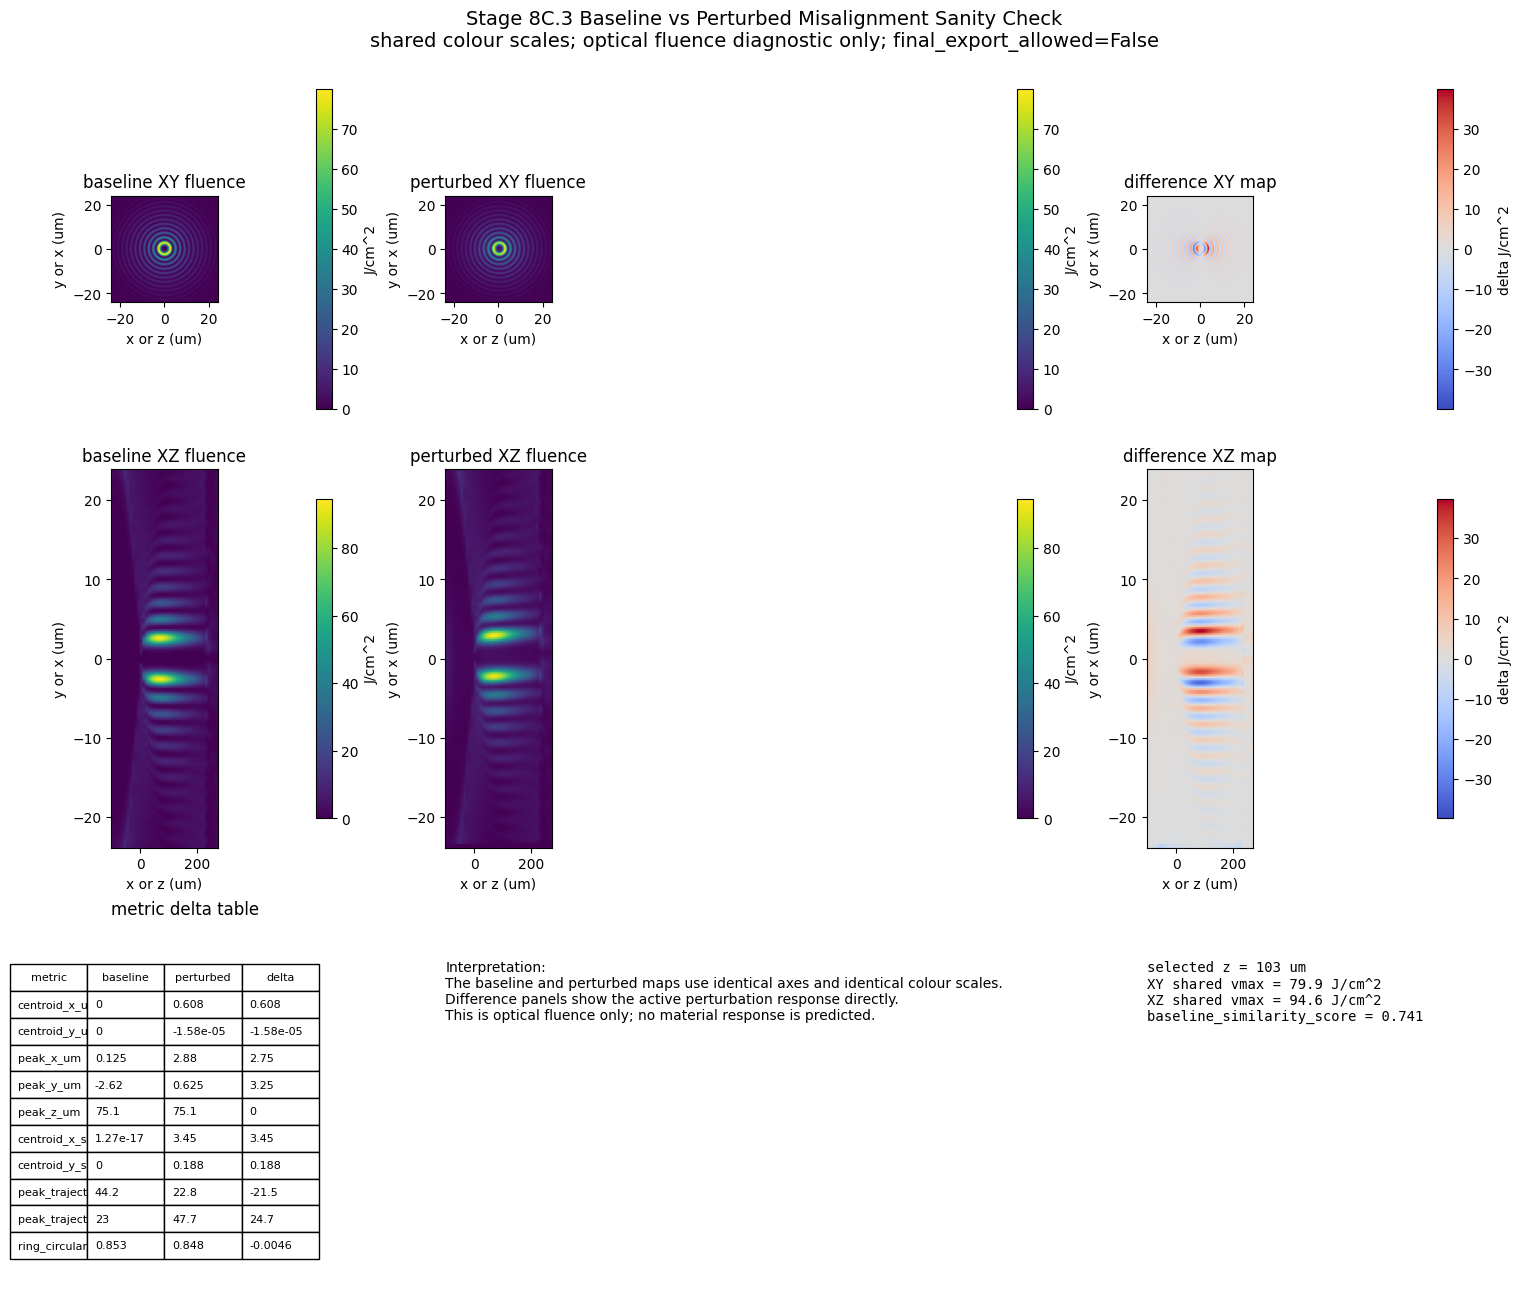

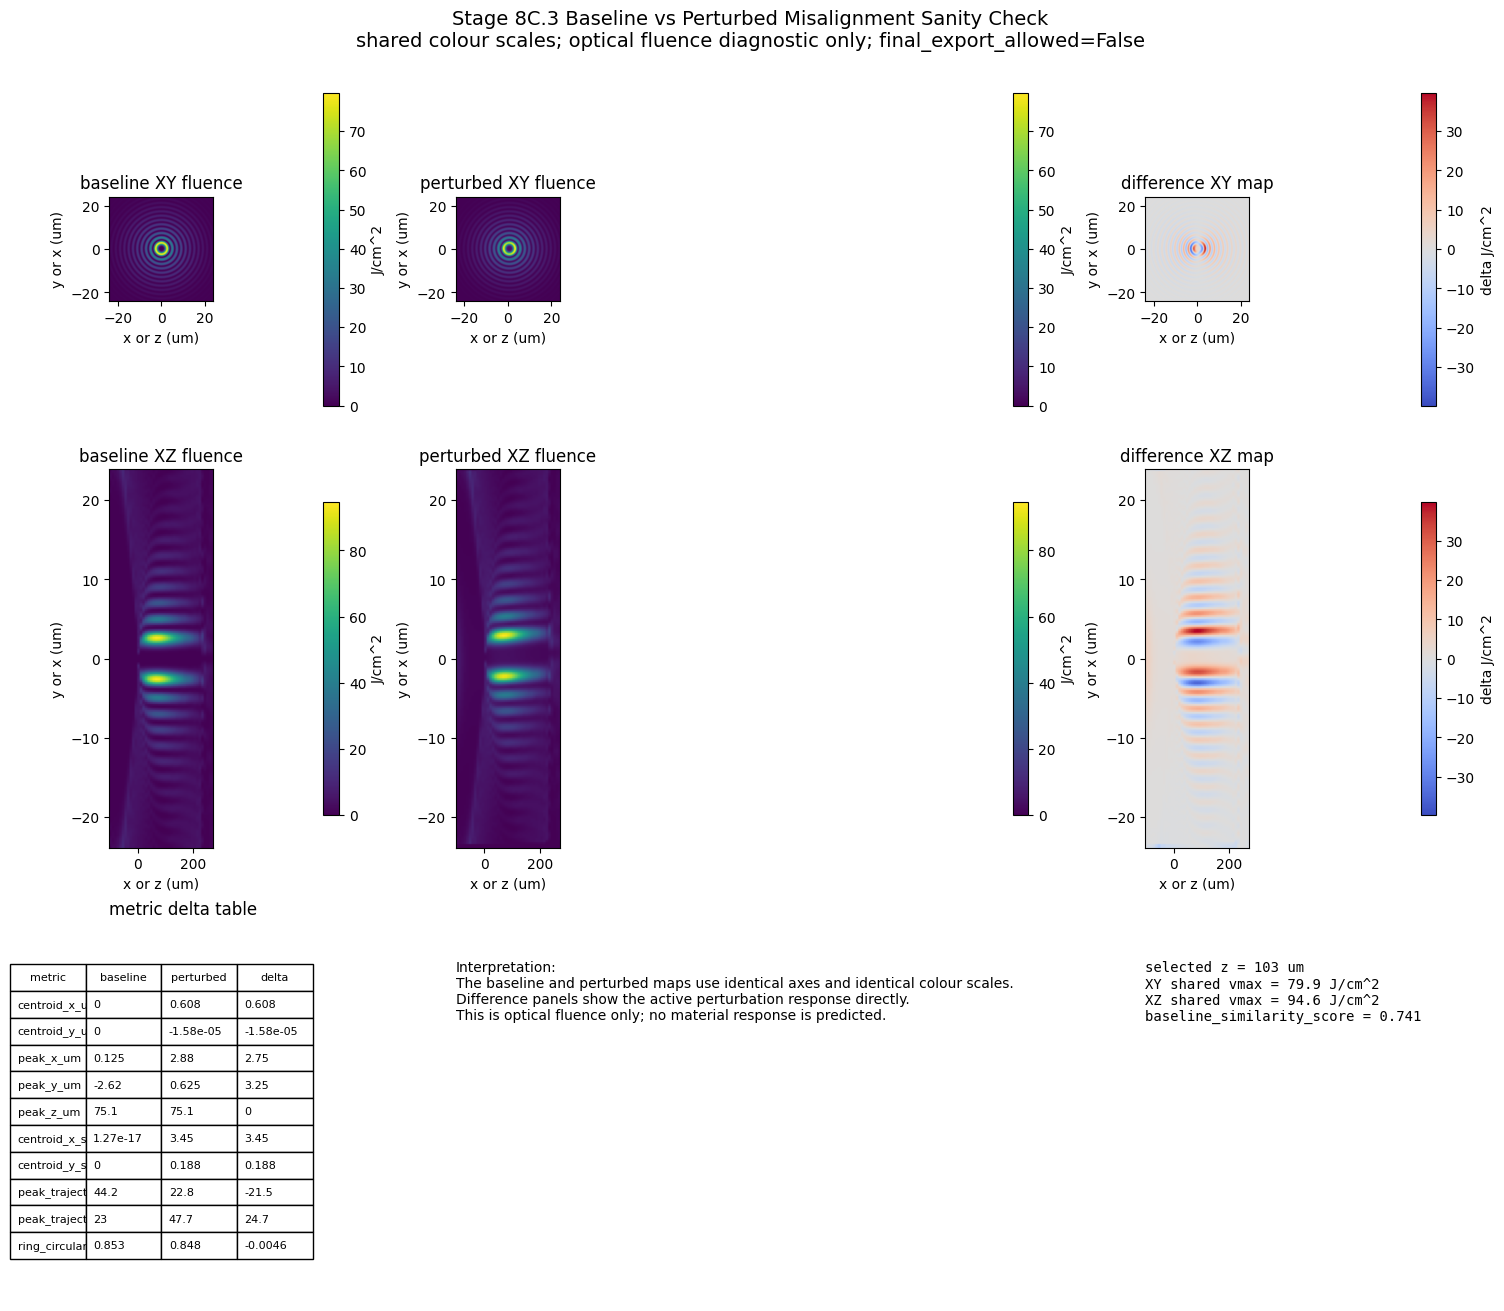

,metric,baseline,perturbed,delta
0,centroid_x_um,0.000000e+00,0.725386,0.725386
1,centroid_y_um,0.000000e+00,-0.000011,-0.000011
2,peak_x_um,1.250000e-01,2.875000,2.750000
3,peak_y_um,-2.625000e+00,0.625000,3.250000
4,peak_z_um,7.512512e+01,75.125121,0.000000
5,centroid_x_span_um,1.274032e-17,3.449957,3.449957
6,centroid_y_span_um,0.000000e+00,0.188175,0.188175
7,peak_trajectory_x_span_um,4.425000e+01,22.750000,-21.500000
8,peak_trajectory_y_span_um,2.300000e+01,47.750000,24.750000
9,ring_circularity_score,8.562252e-01,0.837266,-0.018959


In [13]:
import matplotlib.pyplot as plt

demo_perturbation_controls = dict(controls)
demo_perturbation_controls.update({
    "enable_vortex_centre_offset": True,
    "vortex_centre_offset_x_um": 4.0,
    "enable_beam_tilt": True,
    "beam_tilt_x_mrad": 2.0,
    "enable_zernike_aberrations": True,
    "zernike_coma_x_waves": 0.15,
    "enable_zero_order_leakage": True,
    "zero_order_leakage_fraction": 0.05,
})

perturbation_result = apply_lab_perturbations_to_stack(stack, demo_perturbation_controls)
perturbed_stack = perturbation_result.perturbed_stack
perturbed_fluence_stack = scale_stack_to_fluence(perturbed_stack, ledger.energy_at_sample_uJ)

baseline_degradation_metrics = compute_degradation_metrics(
    stack,
    fluence_stack,
    target_depth_um=focus_depth_um,
    central_roi_half_width_um=central_roi_half_width_um,
)
perturbed_degradation_metrics = compute_degradation_metrics(
    perturbed_stack,
    perturbed_fluence_stack,
    baseline_stack=stack,
    baseline_fluence_result=fluence_stack,
    target_depth_um=focus_depth_um,
    central_roi_half_width_um=central_roi_half_width_um,
    perturbation_metadata=perturbation_result.metadata,
)
metric_delta_rows = metric_delta_table(baseline_degradation_metrics, perturbed_degradation_metrics)
warning_flags = build_warning_flags(
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    diagnostics=diagnostics,
    perturbation_result=perturbation_result,
)

comparison_output_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c3_baseline_vs_perturbed_preview.png"
comparison_fig = plot_baseline_vs_perturbed_comparison(
    stack,
    perturbed_stack,
    fluence_stack,
    perturbed_fluence_stack,
    selected_plane_index=diagnostics["selected_plane_index"],
    output_path=comparison_output_path if save_outputs and stack.source_status != "unit_test_or_demo_only" else None,
    show_caveats=show_caveats,
    dpi=figure_dpi,
)
display(comparison_fig)
plt.show()
plt.close(comparison_fig)

try:
    import pandas as pd
    display(pd.DataFrame(metric_delta_rows))
except Exception:
    display(metric_delta_rows)


> **Legacy diagnostic-visual-transform (superseded by Stage 8C.3R below).** The figures in this section apply perturbations to the *already-propagated* intensity stack, so a hard pupil mask leaves a hard semicircular cut-off at the sample plane and per-plane re-normalisation can restore clipped energy. This is a `diagnostic_visual_transform`, not physics-active. It is kept for continuity; the physically honest path (perturb the complex field **before** propagation) is the **Stage 8C.3R — Component-plane physical realism audit** section that follows.

## Stage 8C.3D - Conservation and Axis Diagnostics

Stage 8C.3D keeps the translation-versus-deformation repair from C3C and adds energy-throughput conservation plus commanded-axis and field-of-view/crop diagnostics. Co-shifting vortex and axicon can be translation-dominated: unregistered similarity may drop, but registered similarity can recover once the centroid is recentered. That case is reported as translation/steering, not as a badly degraded beam.

Passive apertures, finite pupils, SLM active-area clipping, fill-factor losses, and dead-pixel masks reduce the perturbed pulse energy used for fluence scaling. The notebook reports input energy, energy after passive loss, transmitted fraction, peak-to-energy ratio, and the renormalisation factor applied so lost energy is not silently put back.

The headline preview does not multiply those upstream passive aperture masks through already-propagated z-planes. That older diagnostic shortcut made harsh straight XZ cutoffs that looked like propagated physics, so passive clipping is shown as throughput loss unless artifact-risk post-engine spatial clipping is explicitly enabled.

The saved headline preview uses low-order aberrations because they give a smooth field diagnostic without making passive clipping look like propagated physics. The replacement registry still computes relative vortex/axicon misregistration, input beam decentre with finite SLM aperture, beam tilt with finite pupil, objective pupil decentre/clipping, zero-order leakage, and a combined diagnostic stress test; clipping-heavy cases are reviewed in the audit table until a real upstream-aperture propagation path exists. All outputs remain optical/fluence diagnostics only; material response is disabled, and this is not a full pre-propagation component beamline engine.


,control,enabled,classification,physical_placement,implementation_stage,implemented,placement_note
0,enable_beam_tilt,True,diagnostic_active,input complex field,post-propagation diagnostic only,True,beam tilt belongs to input complex-field phase...
1,beam_tilt_x_mrad,True,diagnostic_active,input complex field,post-propagation diagnostic only,True,beam tilt belongs to input complex-field phase...
2,enable_beam_decentre,True,diagnostic_active,input complex field,post-propagation diagnostic only,True,beam decentre belongs to input amplitude/field...
3,beam_decentre_x_um,True,diagnostic_active,input complex field,post-propagation diagnostic only,True,beam decentre belongs to input amplitude/field...
4,enable_vortex_centre_offset,True,diagnostic_active,SLM phase-mask generation,post-propagation diagnostic only,True,vortex centre offset belongs in vortex phase-m...
5,vortex_centre_offset_x_um,True,diagnostic_active,SLM phase-mask generation,post-propagation diagnostic only,True,vortex centre offset belongs in vortex phase-m...
6,enable_axicon_centre_offset,True,diagnostic_active,SLM phase-mask generation,post-propagation diagnostic only,True,axicon centre offset belongs in axicon phase-m...
7,axicon_centre_offset_x_um,True,diagnostic_active,SLM phase-mask generation,post-propagation diagnostic only,True,axicon centre offset belongs in axicon phase-m...
8,enable_slm_active_area,True,diagnostic_active,SLM amplitude/active-area stage,post-propagation diagnostic only,True,finite SLM active area belongs at the SLM aper...
9,slm_active_width_um,True,diagnostic_active,SLM amplitude/active-area stage,post-propagation diagnostic only,True,finite SLM active area belongs at the SLM ampl...


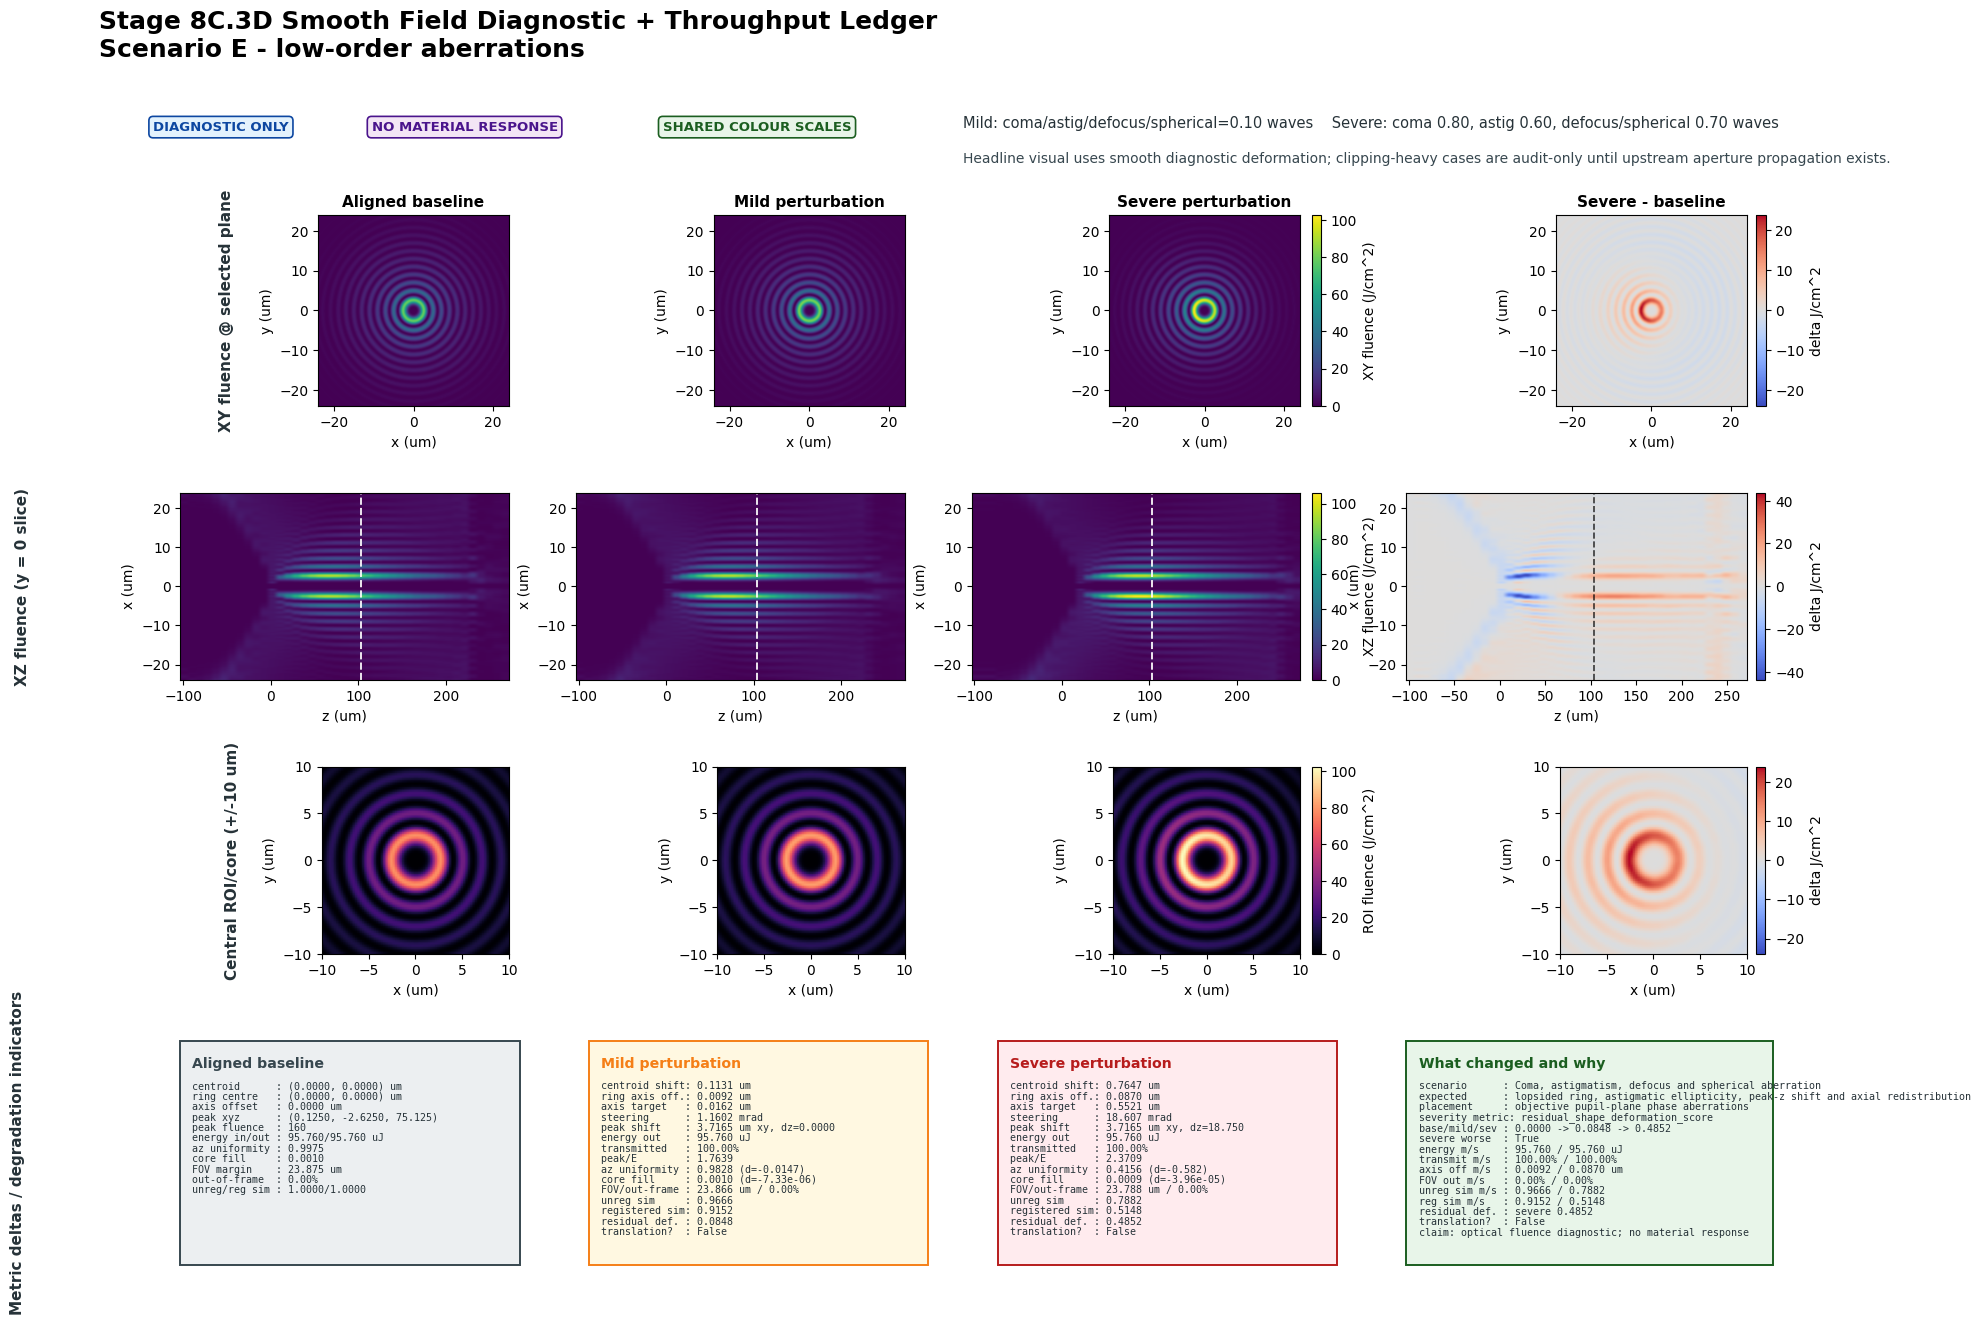

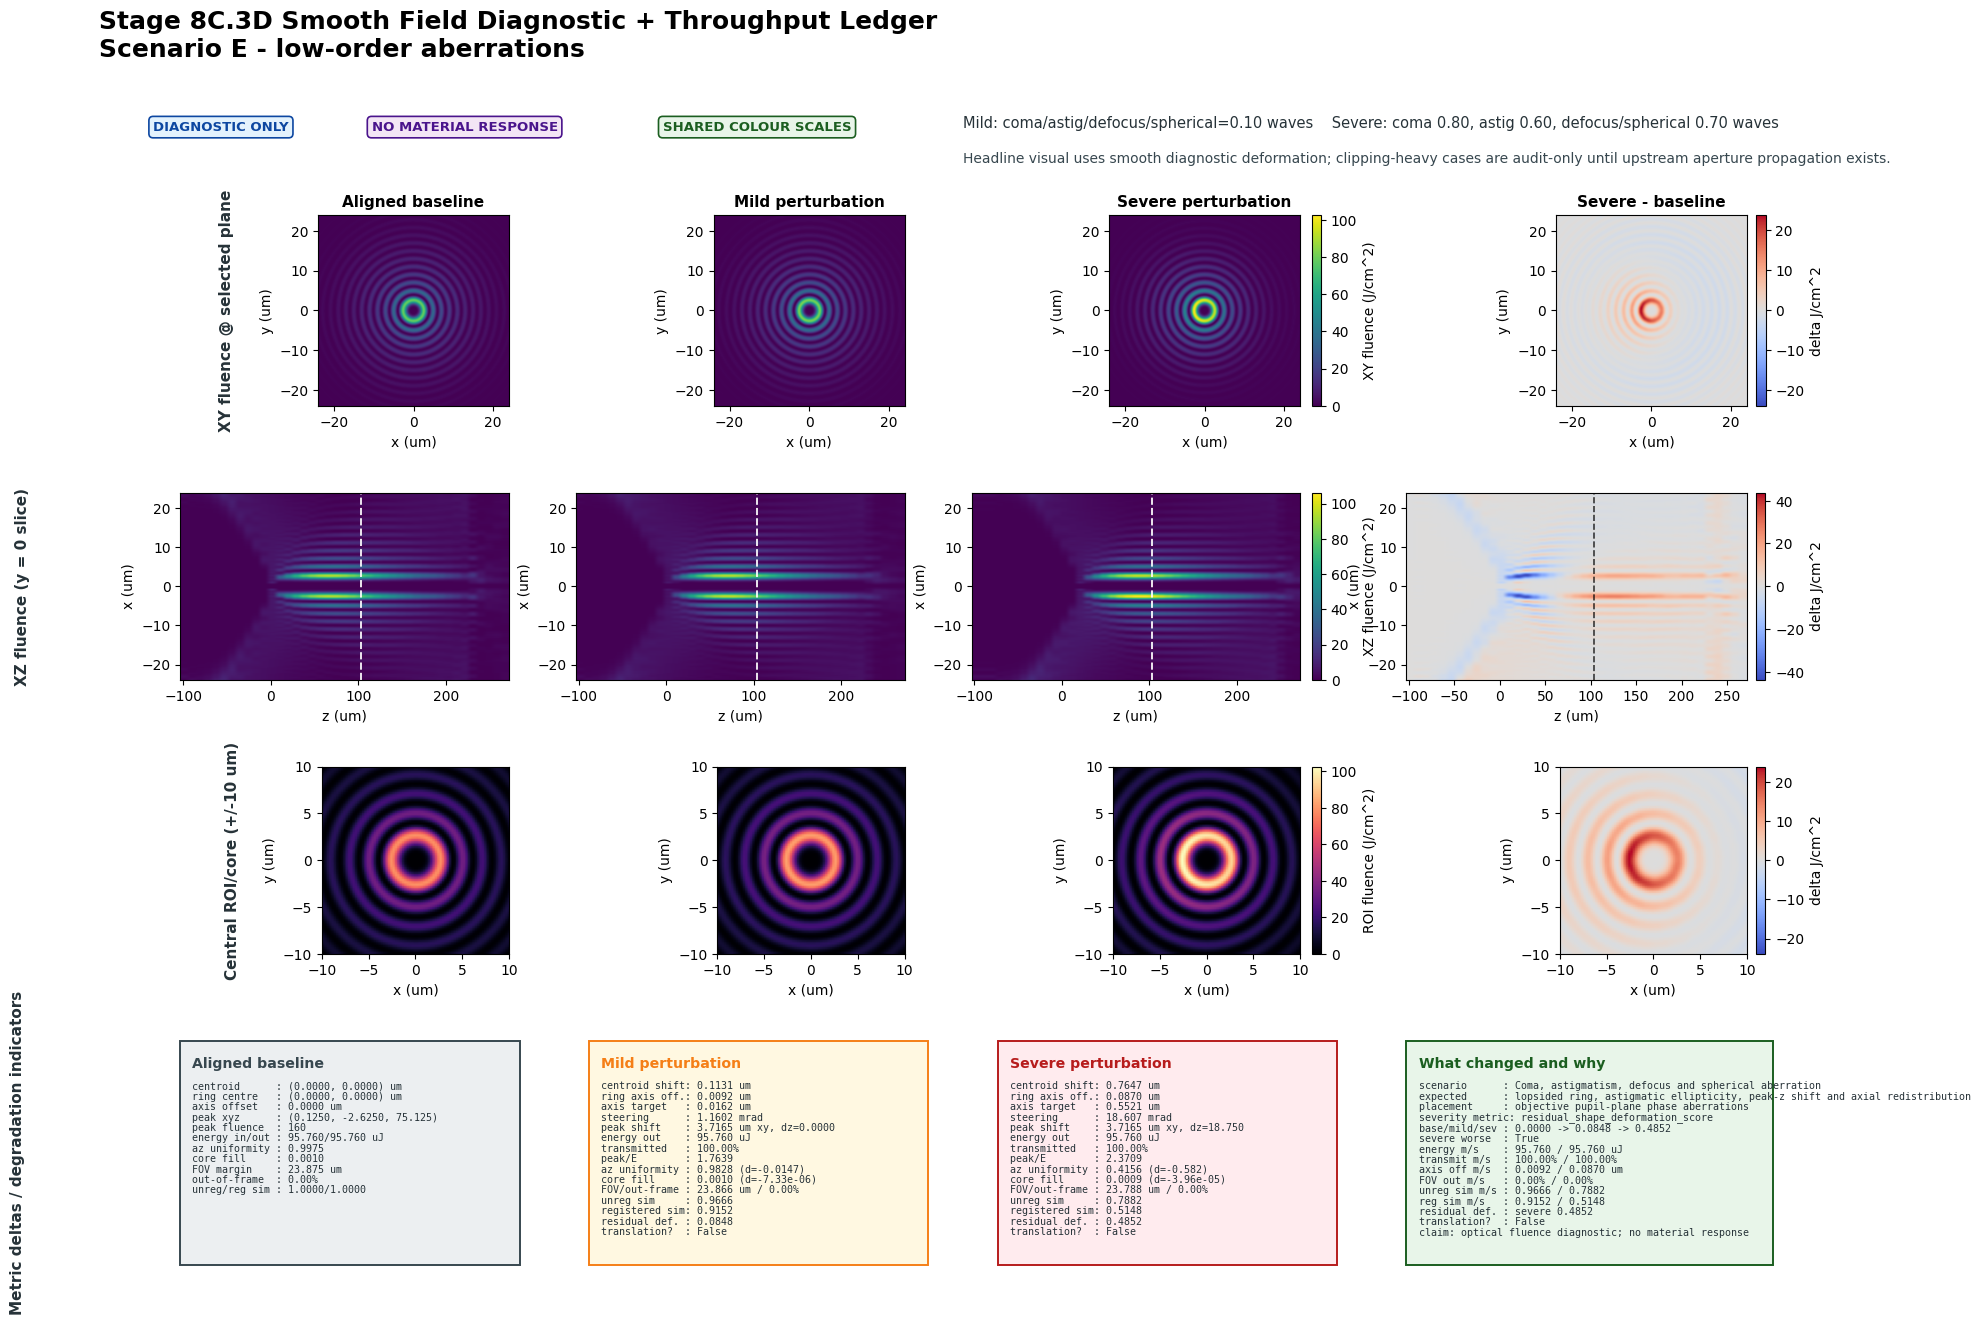

Saved Stage 8C.3D diagnostic preview (final_export_allowed=False) to:
C:\PhD\Code\Publication_Study\outputs\figures\digital_twin\stage8c3d_conservation_axis_diagnostics_preview.png
Headline visual scenario: low_order_aberrations
Scenario severity metric: residual_shape_deformation_score
baseline -> mild -> severe: 0.0 0.08476928547390283 0.4851563110195378
severe energy after passive loss / transmitted_fraction: 95.76021374999999 1.0
severe peak_to_total_energy_ratio / renormalisation_factor_applied: 2.3709254841939233 1.0
severe axis ring/target/FOV/out-of-frame: 0.0869667955344397 0.552145088105528 23.788033204471244 0.0
post_engine_spatial_clipping_applied / visual model: False throughput audit only; no post-propagation spatial crop rendered
severe unregistered/registered similarity: 0.7881650801590562 0.5148436889804622
translation_dominated_boolean: False


,scenario,mild,severe,metric,baseline,mild_value,severe_value,severe_worse_than_mild,energy_after_passive_loss_uJ,transmitted_fraction,...,beam_axis_target_offset_um,field_of_view_margin_um,out_of_frame_fraction,crop_edge_energy_fraction,unregistered_similarity_score,registered_similarity_score,centroid_shift_um,translation_dominated_boolean,residual_shape_deformation_score,counts_as_genuine_degradation
0,Scenario A - relative vortex/axicon misregistr...,vortex x=3 um; axicon fixed,vortex x=8 um; axicon fixed,residual_shape_deformation_score,0.000000,0.260706,0.560474,True,95.760214,1.000000,...,6.229404e+00,22.914363,0.0,0.018760,0.516375,0.439526,1.915302e+00,False,0.560474,True
1,"Scenario A-reverse - axicon shifted, vortex fixed",axicon x=3 um; vortex fixed,axicon x=8 um; vortex fixed,residual_shape_deformation_score,0.000000,0.268892,0.588895,True,95.760214,1.000000,...,4.988268e+00,23.196833,0.0,0.016095,0.526923,0.411105,4.665053e-01,False,0.588895,True
2,Scenario B - input beam decentre + finite SLM ...,beam decentre=0.15R; finite SLM aperture,beam decentre=0.40R; tighter SLM aperture,residual_shape_deformation_score,0.000000,0.190484,0.584722,True,31.977041,0.333928,...,5.257776e+00,14.274434,0.0,0.039849,0.218822,0.415278,8.424848e+00,False,0.584722,True
3,Scenario C - beam tilt + finite pupil,tilt x=2 mrad; finite pupil,tilt x=16 mrad; finite pupil,residual_shape_deformation_score,0.000000,0.059772,0.345185,True,39.578795,0.413311,...,1.239446e+00,23.725560,0.0,0.022962,0.674788,0.654815,1.474905e-01,False,0.345185,True
4,Scenario D - objective pupil decentre and clip...,pupil decentre=0.10R; moderate clipping,pupil decentre=0.35R; strong clipping,pupil_clipped_power_fraction,0.000000,0.559417,0.794884,True,19.641976,0.205116,...,0.000000e+00,23.875000,0.0,0.023535,1.000000,1.000000,0.000000e+00,False,0.000000,True
5,Scenario E - low-order aberrations,coma/astig/defocus/spherical=0.10 waves,"coma 0.80, astig 0.60, defocus/spherical 0.70 ...",residual_shape_deformation_score,0.000000,0.084769,0.485156,True,95.760214,1.000000,...,5.521451e-01,23.788033,0.0,0.016790,0.788165,0.514844,7.646570e-01,False,0.485156,True
6,Scenario F - zero-order leakage,zero-order leakage=0.02,zero-order leakage=0.18,core_fill_fraction,0.000975,0.006318,0.055721,True,95.760214,1.000000,...,8.385651e-18,23.875000,0.0,0.021191,0.921321,0.921321,3.947447e-16,False,0.078679,True
7,Scenario G - diagnostic combined lab stress test,mild combined diagnostic stress,severe combined diagnostic stress,residual_shape_deformation_score,0.000000,0.201323,0.583027,True,11.242655,0.117404,...,7.073877e+00,13.460435,0.0,0.040474,0.262032,0.416973,7.871933e+00,False,0.583027,True
8,Translation diagnostic - co-shifted vortex and...,vortex x=3 um; axicon x=3 um,vortex x=8 um; axicon x=8 um,centroid_shift_um,0.000000,0.578015,1.502953,True,95.760214,1.000000,...,5.489456e-01,22.274434,0.0,0.020395,0.382607,0.922941,1.502953e+00,True,0.077059,False


In [14]:
stage8c3d_controls_for_audit = {
    "enable_beam_tilt": True,
    "beam_tilt_x_mrad": 16.0,
    "enable_beam_decentre": True,
    "beam_decentre_x_um": 9.6,
    "enable_vortex_centre_offset": True,
    "vortex_centre_offset_x_um": 8.0,
    "enable_axicon_centre_offset": True,
    "axicon_centre_offset_x_um": 0.0,
    "enable_slm_active_area": True,
    "slm_active_width_um": 20.0,
    "slm_active_height_um": 20.0,
    "enable_first_order_filter_decentre": True,
    "first_order_filter_decentre_x_px": 5.0,
    "enable_pupil_clipping": True,
    "pupil_radius_um": 8.0,
    "pupil_decentre_x_um": 7.0,
    "enable_zernike_aberrations": True,
    "zernike_coma_x_waves": 0.60,
    "zernike_astig_0_waves": 0.60,
    "zernike_defocus_waves": 0.70,
    "zernike_spherical_waves": 0.70,
    "enable_zero_order_leakage": True,
    "zero_order_leakage_fraction": 0.10,
    "enable_sample_tilt": False,
}
placement_audit_rows = physical_placement_rows_for_controls(
    stage8c3d_controls_for_audit,
    only=stage8c3d_controls_for_audit.keys(),
)
try:
    import pandas as pd
    display(pd.DataFrame(placement_audit_rows))
except Exception:
    display(placement_audit_rows)

sensitivity_output_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c3d_conservation_axis_diagnostics_preview.png"
sensitivity_fig = plot_misalignment_sensitivity_sweep(
    stack,
    ledger.energy_at_sample_uJ,
    baseline_fluence=fluence_stack,
    scenario="low_order_aberrations",
    selected_plane_index=diagnostics["selected_plane_index"],
    target_depth_um=focus_depth_um,
    central_roi_half_width_um=central_roi_half_width_um,
    output_path=sensitivity_output_path if show_caveats else None,
    show_caveats=show_caveats,
    dpi=figure_dpi,
    title="Stage 8C.3D Smooth Field Diagnostic + Throughput Ledger",
)
display(sensitivity_fig)
plt.show()
plt.close(sensitivity_fig)

sensitivity_sweep_result = sensitivity_fig.stage8c3_sensitivity_result
severe_metrics = sensitivity_sweep_result.severe_metrics
print("Saved Stage 8C.3D diagnostic preview (final_export_allowed=False) to:")
print(sensitivity_output_path)
print("Headline visual scenario:", sensitivity_sweep_result.scenario.key)
print("Scenario severity metric:", sensitivity_sweep_result.scenario.degradation_metric)
print(
    "baseline -> mild -> severe:",
    sensitivity_sweep_result.baseline_metrics[sensitivity_sweep_result.scenario.degradation_metric],
    sensitivity_sweep_result.mild_metrics[sensitivity_sweep_result.scenario.degradation_metric],
    severe_metrics[sensitivity_sweep_result.scenario.degradation_metric],
)
print(
    "severe energy after passive loss / transmitted_fraction:",
    severe_metrics["energy_after_passive_loss_uJ"],
    severe_metrics["transmitted_fraction"],
)
print(
    "severe peak_to_total_energy_ratio / renormalisation_factor_applied:",
    severe_metrics["peak_to_total_energy_ratio"],
    severe_metrics["renormalisation_factor_applied"],
)
print(
    "severe axis ring/target/FOV/out-of-frame:",
    severe_metrics["ring_axis_offset_um"],
    severe_metrics["beam_axis_target_offset_um"],
    severe_metrics["field_of_view_margin_um"],
    severe_metrics["out_of_frame_fraction"],
)
print(
    "post_engine_spatial_clipping_applied / visual model:",
    sensitivity_sweep_result.metadata["severe_post_engine_spatial_clipping_applied"],
    sensitivity_sweep_result.metadata["severe_passive_clipping_visual_model"],
)
print(
    "severe unregistered/registered similarity:",
    severe_metrics["unregistered_similarity_score"],
    severe_metrics["registered_similarity_score"],
)
print("translation_dominated_boolean:", severe_metrics["translation_dominated_boolean"])

sensitivity_scenario_rows = []
for scenario_key, scenario_def in build_stage8c3_sensitivity_scenarios().items():
    scenario_sweep = compute_misalignment_sensitivity_sweep(
        stack,
        ledger.energy_at_sample_uJ,
        baseline_fluence=fluence_stack,
        scenario=scenario_key,
        selected_plane_index=diagnostics["selected_plane_index"],
        target_depth_um=focus_depth_um,
        central_roi_half_width_um=central_roi_half_width_um,
    )
    metric = scenario_sweep.scenario.degradation_metric
    severe = scenario_sweep.severe_metrics
    sensitivity_scenario_rows.append({
        "scenario": scenario_def.title,
        "mild": scenario_def.mild_label,
        "severe": scenario_def.severe_label,
        "metric": metric,
        "baseline": scenario_sweep.baseline_metrics[metric],
        "mild_value": scenario_sweep.mild_metrics[metric],
        "severe_value": severe[metric],
        "severe_worse_than_mild": scenario_sweep.metadata["severe_worse_than_mild"],
        "energy_after_passive_loss_uJ": severe["energy_after_passive_loss_uJ"],
        "transmitted_fraction": severe["transmitted_fraction"],
        "peak_to_total_energy_ratio": severe["peak_to_total_energy_ratio"],
        "ring_axis_offset_um": severe["ring_axis_offset_um"],
        "beam_axis_target_offset_um": severe["beam_axis_target_offset_um"],
        "field_of_view_margin_um": severe["field_of_view_margin_um"],
        "out_of_frame_fraction": severe["out_of_frame_fraction"],
        "crop_edge_energy_fraction": severe["crop_edge_energy_fraction"],
        "unregistered_similarity_score": severe["unregistered_similarity_score"],
        "registered_similarity_score": severe["registered_similarity_score"],
        "centroid_shift_um": severe["centroid_shift_um"],
        "translation_dominated_boolean": severe["translation_dominated_boolean"],
        "residual_shape_deformation_score": severe["residual_shape_deformation_score"],
        "counts_as_genuine_degradation": scenario_def.counts_as_genuine_degradation,
    })
try:
    import pandas as pd
    display(pd.DataFrame(sensitivity_scenario_rows))
except Exception:
    display(sensitivity_scenario_rows)


## Stage 8C.3R — Component-plane physical realism audit

The Stage 8C.3 perturbations above were applied to the **already-propagated** intensity stack — a *diagnostic visual transform*. Stage 8C.3R replaces that with a physically honest path: each misalignment control is applied to the **complex field at the optical plane where it lives, before propagation**, and the beam is re-propagated with the locked band-limited angular-spectrum engine.

**You can edit the controls that cause the misalignment** (beam decentre / tilt, independent vortex/axicon centres, finite SLM active area, pupil clip/decentre, Zernike aberrations, zero-order leakage). The vignetting, diffraction, walk-off, ring deformation and core contamination then emerge from genuine propagation — never from a post-stack image edit, so there are no hard black cut-offs at the sample plane.

This section shows the control classification + physical placement, a baseline-vs-physically-perturbed comparison figure, the energy-throughput conservation table, and commanded-vs-actual beam-axis tracking. Claim boundary: **optical fluence diagnostic only — no material response; `final_export_allowed=False`.**

In [ ]:
# ============================================================
# STAGE 8C.3R - COMPONENT-PLANE PHYSICAL LAB-REALISM
# Perturbations are applied to the COMPLEX FIELD before propagation.
# ============================================================
from vbb_study.digital_twin.component_plane_pipeline import (
    ComponentPlaneConfig, run_component_plane_pipeline,
)
from vbb_study.digital_twin.component_plane_metrics import (
    plot_component_plane_reality_preview, compute_axis_tracking,
    compute_energy_throughput, classify_translation_vs_deformation,
)
import pandas as pd
from IPython.display import display

cpr_config = ComponentPlaneConfig()          # full grid; use .fast() for a quick pass

# ---- 1. Headline scenario (baseline / mild / severe) -----------------------
# Pick one: vortex_misregistration, axicon_misregistration, vortex_axicon_coshift,
#   input_decentre_slm_area, beam_tilt_pupil, pupil_decentre_clip,
#   zernike_aberrations, zero_order_leakage, combined_stress
preview_scenario = "pupil_decentre_clip"
cpr_preview_path = Path("outputs/figures/digital_twin/stage8c3r_component_plane_reality_preview.png")
fig_cpr = plot_component_plane_reality_preview(
    preview_scenario, config=cpr_config, output_path=cpr_preview_path,
)
display(fig_cpr)
plt.close(fig_cpr)

# ---- 2. EDIT THESE: the controls that cause the misalignment ---------------
# Toggle / edit and re-run. Each is applied at its real optical plane BEFORE
# propagation, so the misalignment emerges physically.
custom_misalignment = {
    "enable_beam_tilt": True,             "beam_tilt_x_mrad": 12.0,
    "enable_vortex_centre_offset": True,  "vortex_centre_offset_x_um": 6.0,
    "enable_pupil_clipping": True,        "pupil_radius_um": 22.0,
    # "enable_beam_decentre": True,       "beam_decentre_x_um": 10.0,
    # "enable_slm_active_area": True,     "slm_active_width_um": 34.0, "slm_active_height_um": 34.0,
    # "enable_zernike_aberrations": True, "zernike_coma_x_waves": 0.5,
    # "enable_zero_order_leakage": True,  "zero_order_leakage_fraction": 0.2,
}
cpr_baseline = run_component_plane_pipeline({}, config=cpr_config)
cpr_custom   = run_component_plane_pipeline(custom_misalignment, config=cpr_config)

# ---- 3. Energy-throughput conservation table -------------------------------
en = compute_energy_throughput(cpr_custom)
print("Energy throughput (custom misalignment):")
print(f"  input pulse energy       : {en['input_pulse_energy_uJ']:.3f} uJ")
print(f"  transmitted fraction     : {en['transmitted_fraction']:.4f}")
print(f"  sample pulse energy      : {en['sample_pulse_energy_uJ']:.3f} uJ  (no pre-clip renorm)")
print(f"  peak fluence             : {en['peak_fluence_J_cm2']:.3f} J/cm^2")
print(f"  peak / sample-energy     : {en['peak_to_sample_energy_ratio']:.4f}")
print(f"  renormalisation factor   : {en['renormalisation_factor']:.1f}")
display(pd.DataFrame(en["per_plane_ledger"]))

# ---- 4. Commanded vs actual beam-axis tracking -----------------------------
ax_custom = compute_axis_tracking(cpr_custom.propagated_stack)
print("Commanded vs actual beam axis (custom):")
print(f"  commanded axis        : (0.000, 0.000) um")
print(f"  measured ring centre  : ({ax_custom['ring_centre_x_um']:.3f}, {ax_custom['ring_centre_y_um']:.3f}) um")
print(f"  intensity centroid    : ({ax_custom['intensity_centroid_x_um']:.3f}, {ax_custom['intensity_centroid_y_um']:.3f}) um")
print(f"  radial axis error     : {ax_custom['radial_axis_error_um']:.3f} um")
print(f"  steering x / y        : {ax_custom['beam_steering_angle_x_mrad']:.3f} / {ax_custom['beam_steering_angle_y_mrad']:.3f} mrad")
print(f"  trajectory fit R2     : {ax_custom['trajectory_fit_quality']:.3f}")

# ---- 5. Translation / deformation / clipping classification ----------------
cls = classify_translation_vs_deformation(cpr_baseline.propagated_stack, cpr_custom.propagated_stack)
print("Classification (baseline vs custom):")
for k in ["registered_similarity_score", "residual_shape_deformation_score", "centroid_shift_um",
          "translation_dominated_boolean", "throughput_loss_fraction", "core_contamination_fraction"]:
    print(f"  {k:34s}: {cls[k]}")

# ---- 6. Control classification + physical placement ------------------------
print("Component-plane control placement (this engine):")
print("  physically active (applied to the COMPLEX FIELD before propagation):")
print("    input : decentre, ellipticity, rotation, aperture, tilt (phase ramp)")
print("    SLM   : independent vortex/axicon centres, quantisation, phase noise,")
print("            dead pixels, fill factor, active-area clip, zero-order carrier")
print("    pupil : clip / decentre, Zernike defocus / astig / coma / spherical")
print("  warning-only (no explicit 4F / relay plane in this engine, NOT faked):")
for w in cpr_custom.warnings:
    print("    -", w)
print("Claim boundary: optical fluence diagnostic only; no material response;",
      "final_export_allowed =", cpr_custom.final_export_allowed)


## Stage 8C.3R.1 — Free-Space Reference-Plane Validation and Sensitivity Atlas

This section **validates** the Stage 8C.3R upstream component-plane model at a **free-space reference plane** before any material model exists.

**This is a free-space / reference-plane optical study only — `n = 1.0`.** There is **no sample material model**, no interface, and no chosen material / thickness / surface / focus depth / objective geometry. The endpoint is the *post-objective free-space reference plane* (the intended sample-entrance reference plane in air). It is **not** an in-material plane and is never labelled as one. Sample / interface / material controls remain `future material/interface study`.

It reports: free-space settings, the component-plane audit, the energy-throughput validation (no hidden renormalisation), the peak-concentration validation, commanded-vs-actual beam-axis tracking, the analytical beam-tilt validation, the crop/FOV convergence table, and the individual diagnostic sensitivity atlas. Each sweep is a **diagnostic sensitivity sweep, not an experimentally measured laboratory tolerance.** Claim boundary: optical fluence diagnostic only; `final_export_allowed=False`.

In [ ]:
# ============================================================
# STAGE 8C.3R.1 - FREE-SPACE REFERENCE-PLANE VALIDATION (n = 1.0)
# Validates the upstream component-plane model BEFORE any material model.
# ============================================================
from vbb_study.digital_twin.component_plane_pipeline import ComponentPlaneConfig, run_component_plane_pipeline
from vbb_study.digital_twin.component_plane_metrics import run_component_plane_scenario
from vbb_study.digital_twin.component_plane_validation import (
    zero_control_equivalence, compute_energy_audit, validate_beam_tilt, fov_convergence_check,
)
from vbb_study.digital_twin.component_plane_figures import (
    plot_reference_plane_energy_axis_validation, plot_individual_sensitivity_atlas, plot_fov_convergence_check,
)
import pandas as pd
from IPython.display import display

cpr1_config = ComponentPlaneConfig()   # full grid; .fast() for a quick pass

# ---- Free-space / reference-plane settings --------------------------------
print("FREE-SPACE REFERENCE-PLANE SETTINGS (no material model):")
print(f"  propagation medium n   : {cpr1_config.n_medium:.3f}  (free-space reference)")
print(f"  wavelength             : {cpr1_config.wavelength_nm:.1f} nm")
print(f"  grid                   : N={cpr1_config.grid_N}, dx={cpr1_config.dx_um} um, FOV={cpr1_config.grid_N*cpr1_config.dx_um:.0f} um")
print(f"  vortex charge ell      : {cpr1_config.ell}")
print(f"  axicon kr              : {cpr1_config.kr_rad_per_um} rad/um")
print(f"  z reference planes     : {cpr1_config.n_z} from {cpr1_config.z_min_um} to {cpr1_config.z_max_um} um")
print("  endpoint               : post-objective free-space reference plane (intended sample-entrance, n=1.0)")

# ---- B. Zero-control equivalence vs canonical free-space reference ---------
eq = zero_control_equivalence(cpr1_config)
print("\nZERO-CONTROL EQUIVALENCE vs canonical free-space reference:")
print(f"  complex-field similarity : {eq['complex_field_similarity']:.10f}")
print(f"  intensity similarity     : {eq['intensity_similarity']:.10f}")
print(f"  fluence similarity       : {eq['fluence_similarity']:.10f}")
print(f"  raw field-power rel diff : {eq['raw_field_power_rel_diff']:.2e}")
print(f"  axis position diff       : {eq['axis_position_diff_um']:.2e} um")
print(f"  ring radius meas/anal    : {eq['ring_radius_measured_um']:.2f} / {eq['ring_radius_analytical_um']:.2f} um (rel {eq['ring_radius_rel_diff']*100:.1f}%)")
print(f"  on-axis core null ratio  : {eq['core_null_ratio']:.3f}")
print(f"  EQUIVALENT within tol    : {eq['equivalent_within_tolerance']}   physically valid Bessel-Gauss: {eq['physically_valid_bessel_gauss']}")

# ---- C. Energy-throughput + peak-concentration validation -----------------
scenario_key = "pupil_decentre_clip"
res = run_component_plane_scenario(scenario_key, config=cpr1_config)
audits = {
    "baseline": compute_energy_audit(res.baseline, fov_reliable=True),
    "mild": compute_energy_audit(res.mild, baseline_run=res.baseline, fov_reliable=True),
    "severe": compute_energy_audit(res.severe, baseline_run=res.baseline, fov_reliable=True),
}
print(f"\nENERGY / NORMALISATION AUDIT  (scenario: {scenario_key})")
erows = []
for name, au in audits.items():
    erows.append({
        "case": name, "transmitted": round(au["transmitted_fraction"], 3),
        "ref_energy_uJ": round(au["sample_pulse_energy_uJ"], 2),
        "peak_J_cm2": round(au["peak_fluence_J_cm2"], 1),
        "peak/ref_E": round(au["peak_to_reference_energy_ratio"], 3),
        "core_frac": round(au["core_energy_fraction"], 3),
        "annular_frac": round(au["annular_energy_fraction"], 3),
        "side_frac": round(au["side_lobe_energy_fraction"], 3),
        "renorm": au["renormalisation_factor"],
        "energy_valid": au["energy_accounting_valid"],
        "peak_rise": au["peak_rise_status"],
    })
display(pd.DataFrame(erows))

# ---- D. Commanded-axis vs actual-axis summary -----------------------------
sa = res.severe_axis
print("COMMANDED vs ACTUAL BEAM AXIS (severe):")
print(f"  commanded (0,0)  ring ({sa['ring_centre_x_um']:.3f},{sa['ring_centre_y_um']:.3f}) centroid ({sa['intensity_centroid_x_um']:.3f},{sa['intensity_centroid_y_um']:.3f})")
print(f"  ring fit quality {sa['ring_fit_quality']:.3f}  radial axis error {sa['radial_axis_error_um']:.3f} um  steering_x {sa['beam_steering_angle_x_mrad']:.2f} mrad  fit R2 {sa['trajectory_fit_quality']:.3f}")

# ---- E. Beam-tilt analytical validation -----------------------------------
tilt = validate_beam_tilt(24.0, config=cpr1_config)
print("BEAM-TILT VALIDATION (24 mrad):")
print(f"  expected slope {tilt['expected_slope_x']:.5f}  measured {tilt['measured_slope_x']:.5f}  rel err {tilt['relative_slope_error']*100:.1f}%  fit R2 {tilt['trajectory_fit_quality']:.3f}  px {tilt['grid_pixels_of_displacement']:.1f}  agrees {tilt['agrees_within_tolerance']}")

# ---- F. Crop / FOV convergence table --------------------------------------
fov_cases = {
    "baseline": {},
    "beam tilt 24 mrad": {"enable_beam_tilt": True, "beam_tilt_x_mrad": 24.0},
    "pupil clip+decentre": {"enable_pupil_clipping": True, "pupil_radius_um": 12.0, "pupil_decentre_x_um": 12.0},
}
print("CROP / FOV CONVERGENCE (standard vs expanded grid):")
frows = []
for name, ctrl in fov_cases.items():
    c = fov_convergence_check(ctrl, config=cpr1_config)
    frows.append({"case": name, "N_std->exp": f"{c['standard_grid_N']}->{c['expanded_grid_N']}",
                  "peak_rel_%": round(c["peak_fluence_rel_diff"]*100, 2),
                  "oof_%": round(c["out_of_frame_fraction"]*100, 3),
                  "margin_um": round(c["field_of_view_margin_um"], 1),
                  "reliability": c["metric_convergence_status"]})
display(pd.DataFrame(frows))

# ---- Figures (inline + saved) ---------------------------------------------
D = "outputs/figures/digital_twin/"
fig1 = plot_reference_plane_energy_axis_validation(scenario_key, config=cpr1_config,
        output_path=D+"stage8c3r1_reference_plane_energy_axis_validation.png")
display(fig1); plt.close(fig1)
fig3 = plot_fov_convergence_check(config=cpr1_config,
        output_path=D+"stage8c3r1_fov_convergence_check.png")
display(fig3); plt.close(fig3)
fig2 = plot_individual_sensitivity_atlas(config=cpr1_config,
        output_path=D+"stage8c3r1_individual_sensitivity_atlas.png")
display(fig2); plt.close(fig2)

print("\nCLAIM BOUNDARY: optical fluence diagnostic only; free-space n=1.0 reference plane;")
print("no material model; every sweep is a diagnostic sensitivity sweep, not a measured")
print("laboratory tolerance; final_export_allowed = False.")


## Stage 8C.3R.2 — Annular Axis Tracking and Diagnostic Sensitivity Study

This section locks the annular-axis diagnostic used by the free-space component-plane study. The raw brightest point on a vortex/Bessel ring is azimuthally degenerate, so it is rendered only as a secondary diagnostic. The primary hierarchy is fitted annular ring centre, fitted dark-core centre, central ROI centroid, and optional phase singularity when a complex transverse field is available.

**Boundary:** free-space/reference-plane optical diagnostic only (`n = 1.0`); no material response, sample interface, writing model, 3D visualisation, GUI work, or calibrated laboratory tolerance. `final_export_allowed=False`.


In [ ]:
# ============================================================
# STAGE 8C.3R.2 - ANNULAR AXIS TRACKING AND DIAGNOSTIC SENSITIVITY STUDY
# Free-space n=1.0; raw annular peak is diagnostic only.
# ============================================================
from vbb_study.digital_twin.component_plane_pipeline import ComponentPlaneConfig, run_component_plane_pipeline
from vbb_study.digital_twin.annular_axis_tracking import RAW_PEAK_LABEL, estimate_annular_axis
from vbb_study.digital_twin.component_plane_metrics import (
    DIAGNOSTIC_SWEEP_LABEL, build_response_curve_families, run_response_curve, compute_axis_tracking,
)
from vbb_study.digital_twin.component_plane_validation import validate_beam_tilt, fov_convergence_check
from vbb_study.digital_twin.component_plane_figures import (
    plot_annular_axis_tracking_validation, plot_fov_convergence_check,
    plot_individual_response_curves, plot_free_space_study_summary,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# User-editable controls -----------------------------------------------------
axis_estimator_mode = "auto"          # auto (recommended), ring_fit, core_fit, roi_centroid
show_raw_peak_diagnostic = True        # show/hide the raw brightest-pixel marker
_ALLOWED_AXIS_MODES = {"auto", "ring_fit", "core_fit", "roi_centroid"}
assert axis_estimator_mode in _ALLOWED_AXIS_MODES, f"axis_estimator_mode must be one of {_ALLOWED_AXIS_MODES}"

cpr2_config = ComponentPlaneConfig.fast(grid_N=192, n_z=32, dx_um=0.5)
D = "outputs/figures/digital_twin/"

display(Markdown(
    "**Axis estimator hierarchy:** 1. fitted annular ring centre; "
    "2. fitted dark-core centre; 3. central ROI centroid; "
    "4. phase singularity when complex phase exists. "
    f"Raw brightest pixel status: `{RAW_PEAK_LABEL}`. "
    "It is not a primary beam-axis metric for annular fields."
))

# Clean baseline sanity: fitted ring/core near the commanded axis, raw peak on the annulus.
base = run_component_plane_pipeline({}, config=cpr2_config).propagated_stack
sel = int(np.argmax(base.intensity_zyx.max(axis=(1, 2))))
est = estimate_annular_axis(base.intensity_zyx[sel], base.x_um, base.y_um)
axis = compute_axis_tracking(base, plane_index=sel, core_radius_um=2.0)
print("CLEAN BASELINE ANNULAR AXIS SANITY")
print(f"  selected z plane       : index {sel}, z={base.z_um[sel]:.2f} um")
print(f"  fitted ring centre     : ({est['ring_centre_x_um']:.3f}, {est['ring_centre_y_um']:.3f}) um")
print(f"  fitted core centre     : ({est['core_centre_x_um']:.3f}, {est['core_centre_y_um']:.3f}) um")
print(f"  selected axis method   : {est['beam_axis_method']} / {est['beam_axis_reliability']}")
print(f"  selected axis error    : {est['beam_axis_error_um']:.3f} um")
print(f"  raw brightest pixel    : ({est['brightest_pixel_x_um']:.2f}, {est['brightest_pixel_y_um']:.2f}) um")
print(f"  raw peak status        : {est['brightest_pixel_status']}")

# Tilt validation uses fitted axis trajectory, not raw brightest pixels.
tilt = validate_beam_tilt(24.0, config=cpr2_config)
print()
print("FITTED-AXIS TILT VALIDATION (24 mrad)")
print(f"  expected slope x       : {tilt['expected_slope_x']:.6f}")
print(f"  measured slope x       : {tilt['measured_slope_x']:.6f}")
print(f"  relative error         : {tilt['relative_error']*100:.2f}%")
print(f"  fit quality            : {tilt['fit_quality']:.3f}")
print(f"  grid displacement      : {tilt['grid_resolved_displacement']:.1f} px")

# FOV convergence: raw peak is shown but cannot drive the reliability state.
fov = fov_convergence_check({}, config=cpr2_config)
display(pd.DataFrame([{
    "status": fov["metric_convergence_status"],
    "ring_diff_um": fov["ring_centre_difference_um"],
    "core_diff_um": fov["core_centre_difference_um"],
    "axis_traj_diff_um": fov["axis_trajectory_difference_um"],
    "raw_peak_diff_um_diag_only": fov["raw_peak_position_difference_um"],
    "peak_rel_%": 100.0 * fov["peak_fluence_rel_diff"],
    "raw_peak_status": fov["raw_peak_status"],
}]))

# Response curves: diagnostic rankings, not experimentally measured tolerances.
print()
print("Running C3R.2 response curves:", DIAGNOSTIC_SWEEP_LABEL)
c3r2_curve_results = {
    key: run_response_curve(key, config=cpr2_config)
    for key in build_response_curve_families()
}
summary_rows = []
for key, curve in c3r2_curve_results.items():
    rows = list(curve.rows)
    summary_rows.append({
        "family": key,
        "max_axis_error_um": max(r["axis_error_um"] for r in rows),
        "max_residual_deformation": max(r["residual_shape_deformation"] for r in rows),
        "max_core_contamination": max(r["core_contamination_fraction"] for r in rows),
        "min_transmitted_fraction": min(r["transmitted_fraction"] for r in rows),
        "label": curve.label,
    })
display(pd.DataFrame(summary_rows))

fig_axis = plot_annular_axis_tracking_validation(
    config=cpr2_config, axis_estimator_mode=axis_estimator_mode,
    show_raw_peak_diagnostic=show_raw_peak_diagnostic,
    output_path=D + "stage8c3r2_annular_axis_tracking_validation.png",
)
display(fig_axis); plt.close(fig_axis)

fig_fov = plot_fov_convergence_check(config=cpr2_config)
display(fig_fov); plt.close(fig_fov)

fig_resp = plot_individual_response_curves(
    config=cpr2_config, curve_results=c3r2_curve_results,
    output_path=D + "stage8c3r2_individual_response_curves.png",
)
display(fig_resp); plt.close(fig_resp)

fig_summary = plot_free_space_study_summary(
    config=cpr2_config, curve_results=c3r2_curve_results,
    output_path=D + "stage8c3r2_free_space_study_summary.png",
)
display(fig_summary); plt.close(fig_summary)

print()
print("CLAIM BOUNDARY: free-space n=1.0 optical/fluence diagnostics only;")
print("raw annular peak is diagnostic only; no material/interface/writing model;")
print("response curves are diagnostic sensitivity sweeps, not measured lab tolerances;")
print("final_export_allowed = False. Next stage remains planned only; Stage 8D has not been started.")


## Stage 8C.3R.3 - Route-Aware Physical-Axicon Alignment Study

This section records the earlier location-aware physical-axicon diagnostic. It is superseded by the Stage 8C.3R.4 component-owned physical-axicon route scaffold correction below: field-state controls remain useful only as labelled boundary conditions, while represented optic errors must belong to named components and propagate through downstream segments/elements.

**Boundary:** free-space/reference-plane optical diagnostics only; no material response or Stage 8D.


In [ ]:
# ============================================================
# STAGE 8C.3R.3 - ROUTE-AWARE PHYSICAL-AXICON ALIGNMENT STUDY
# Location-aware perturbations; free-space n=1.0; diagnostic only.
# ============================================================
from vbb_study.digital_twin.route_aware_axicon import (
    DIAGNOSTIC_GEOMETRY_NOTE, DIAGNOSTIC_SWEEP_LABEL,
    RouteAwareAxiconConfig, build_route_perturbation_records, holographic_slm_route_declarations,
    physical_axicon_route_graph, run_route_aware_axicon_pipeline,
    build_axicon_alignment_sweep_families, run_axicon_alignment_sweep,
    plot_route_aware_axicon_pipeline, plot_upstream_vs_post_axicon_tilt_comparison,
    plot_axicon_alignment_sensitivity_atlas,
)
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

# User-editable controls -----------------------------------------------------
route_mode = "physical_axicon"                 # physical_axicon / holographic_slm
perturbation_location = "source_plane"         # source_plane, before_physical_axicon, after_physical_axicon, post_axicon_diagnostic_boundary
pre_axicon_distance_mm = 0.80                  # diagnostic demo geometry, not measured bench distance
post_axicon_distance_mm = 0.225                # diagnostic demo geometry, not measured bench distance
source_tilt_x_mrad = 12.0
source_tilt_y_mrad = 0.0
beam_decentre_x_um = 0.0
beam_decentre_y_um = 0.0
axicon_centre_x_um = 0.0
axicon_centre_y_um = 0.0
axicon_clear_aperture_radius_um = 42.0
input_beam_radius_um = 22.0
enable_post_axicon_steering_test = False       # analytical downstream steering validation, not upstream fault
post_axicon_steering_x_mrad = 12.0

if enable_post_axicon_steering_test:
    active_tilt_location = "after_physical_axicon"
    active_tilt_x_mrad = post_axicon_steering_x_mrad
else:
    active_tilt_location = perturbation_location
    active_tilt_x_mrad = source_tilt_x_mrad

cpr3_config = RouteAwareAxiconConfig.fast(
    route_mode=route_mode,
    grid_N=192,
    dx_um=0.5,
    n_z=32,
    pre_axicon_distance_mm=pre_axicon_distance_mm,
    post_axicon_distance_mm=post_axicon_distance_mm,
    input_beam_radius_um=input_beam_radius_um,
    field_tilt_x_mrad=active_tilt_x_mrad,
    field_tilt_y_mrad=source_tilt_y_mrad,
    field_tilt_location=active_tilt_location,
    beam_decentre_x_um=beam_decentre_x_um,
    beam_decentre_y_um=beam_decentre_y_um,
    beam_decentre_location=perturbation_location,
    physical_axicon_centre_x_um=axicon_centre_x_um,
    physical_axicon_centre_y_um=axicon_centre_y_um,
    physical_axicon_clear_aperture_radius_um=axicon_clear_aperture_radius_um,
)

D = "outputs/figures/digital_twin/"

route_graph_rows = [n.__dict__ for n in physical_axicon_route_graph(cpr3_config)]
display(Markdown(f"**Route geometry note:** {DIAGNOSTIC_GEOMETRY_NOTE}"))
display(pd.DataFrame(route_graph_rows))

records = build_route_perturbation_records(cpr3_config)
if route_mode == "holographic_slm":
    records = records + holographic_slm_route_declarations()
control_rows = []
for r in records:
    d = r.as_dict()
    control_rows.append({
        "type": d["perturbation_type"],
        "parameter": d["parameter_name"],
        "magnitude": d["magnitude"],
        "units": d["units"],
        "physical injection location": d["injection_location"],
        "implemented status": d["active / warning-only / future status"],
        "downstream elements affected": ", ".join(d["downstream_elements_affected"]),
    })
display(pd.DataFrame(control_rows))

run = run_route_aware_axicon_pipeline(config=cpr3_config)
m = run.axicon_incidence_metrics
print("AXICON-PLANE INCIDENCE DIAGNOSTICS")
print(f"  field tilt location        : {m['field_tilt_injection_location']}")
print(f"  incident centroid          : ({m['incident_centroid_x_um']:.2f}, {m['incident_centroid_y_um']:.2f}) um")
print(f"  incident angle             : ({m['incident_angle_x_mrad']:.2f}, {m['incident_angle_y_mrad']:.2f}) mrad")
print(f"  beam-to-axicon offset      : {m['relative_beam_to_axicon_offset_um']:.2f} um")
print(f"  axicon overlap             : {m['axicon_aperture_overlap_fraction']:.3f}")
print(f"  axicon transmitted fraction: {m['axicon_transmitted_fraction']:.3f}")
print(f"  predicted/measured walkoff : {m['upstream_tilt_predicted_walkoff_um']:.2f} / {m['upstream_tilt_measured_walkoff_um']:.2f} um")
print(f"  walkoff model error        : {m['walkoff_model_error_um']:.2f} um")

# Diagnostic sweeps, not laboratory tolerances.
print()
print("Running route-aware axicon sweeps:", DIAGNOSTIC_SWEEP_LABEL)
c3r3_sweep_results = {
    key: run_axicon_alignment_sweep(key, config=cpr3_config)
    for key in build_axicon_alignment_sweep_families()
}
summary_rows = []
for key, curve in c3r3_sweep_results.items():
    rows = list(curve.rows)
    summary_rows.append({
        "family": key,
        "max_walkoff_um": max(r["axicon_plane_walkoff_um"] for r in rows),
        "min_overlap": min(r["axicon_aperture_overlap_fraction"] for r in rows),
        "min_transmitted": min(r["transmitted_fraction"] for r in rows),
        "max_axis_error_um": max(r["reference_plane_beam_axis_error_um"] for r in rows),
        "label": curve.label,
    })
display(pd.DataFrame(summary_rows))

fig_pipe = plot_route_aware_axicon_pipeline(
    config=cpr3_config,
    output_path=D + "stage8c3r3_route_aware_axicon_pipeline.png",
)
display(fig_pipe); plt.close(fig_pipe)

fig_loc = plot_upstream_vs_post_axicon_tilt_comparison(
    config=cpr3_config,
    output_path=D + "stage8c3r3_upstream_vs_post_axicon_tilt_comparison.png",
)
display(fig_loc); plt.close(fig_loc)

fig_atlas = plot_axicon_alignment_sensitivity_atlas(
    config=cpr3_config,
    sweep_results=c3r3_sweep_results,
    output_path=D + "stage8c3r3_axicon_alignment_sensitivity_atlas.png",
)
display(fig_atlas); plt.close(fig_atlas)

print()
print("CLAIM BOUNDARY: free-space n=1.0 route-aware optical diagnostics only;")
print("perturbations declare type, magnitude, physical injection location, downstream elements, and status;")
print("no material/interface/writing model; sweeps are diagnostic, not measured lab tolerances;")
print("final_export_allowed = False. Next stage remains planned only; Stage 8D has not been started.")


## Stage 8C.3R.4.1 - Component-Owned Physical-Axicon Route Scaffold

The physical-axicon route is now inspected as a component-owned scaffold. Active physics is limited to the source complex field, input aperture, free-space propagation segments, thin scalar physical axicon phase/clear aperture, and free-space reference-plane diagnostics. Steering mirrors, SLM/4F/relay, pupil/objective optics, and mechanical axicon tilt remain warning-only or future-stage.


In [ ]:
# ============================================================
# STAGE 8C.3R.4.1 - PHYSICAL-AXICON ROUTE SEMANTICS CLEANUP
# Component-owned physical-axicon route scaffold; diagnostic free-space n=1.0 only.
# ============================================================
from vbb_study.digital_twin.route_aware_axicon import (
    RouteAwareAxiconConfig, run_route_aware_axicon_pipeline,
    build_physical_axicon_beamline, build_route_component_declarations,
    route_inspection_rows, plot_component_route_inspection,
)
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
D = "outputs/figures/digital_twin/"

# Representative component-owned perturbations. These are diagnostic demo
# values, not measured bench tolerances.
c3r4_config = RouteAwareAxiconConfig.fast(
    grid_N=192,
    dx_um=0.5,
    n_z=32,
    input_beam_radius_um=22.0,
    input_aperture_centre_x_um=4.0,
    physical_axicon_centre_x_um=6.0,
    physical_axicon_axial_offset_um=50.0,
    field_tilt_x_mrad=8.0,
    field_tilt_location="before_physical_axicon",
)

component_rows = []
for c in build_route_component_declarations(c3r4_config):
    d = c.as_dict()
    component_rows.append({
        "component_id": d["component_id"],
        "type": d["component_type"],
        "location": d["physical_location"],
        "next_mm": d["distance_to_next_element_mm"],
        "pose": d["physical_pose"],
        "represented": d["represented_by_current_engine"],
        "model_available": d["physical_model_available"],
        "supported_modes": ", ".join(d["misalignment_modes_currently_supported"]),
        "status": d["active / warning-only / future status"],
        "downstream": ", ".join(d["downstream_elements_affected"]),
    })
display(pd.DataFrame(component_rows))

c3r4_run = run_route_aware_axicon_pipeline(config=c3r4_config)
inspection_rows = []
for row in route_inspection_rows(c3r4_run):
    inspection_rows.append({
        "component": row["component_id"],
        "type": row["component_type"],
        "next_mm": row["distance_to_next_element_mm"],
        "pose": row["actual_pose_error"],
        "energy_uJ": f"{row['energy before (uJ)']:.2f} -> {row['energy after (uJ)']:.2f}",
        "centroid_um": row["centroid after (um)"],
        "angle_mrad": row["angle after (mrad)"],
        "overlap": row["aperture overlap"],
        "transform_applied": row["transform_applied"],
        "status": row["model status"],
        "warnings": "; ".join(row["warnings"]),
    })
display(pd.DataFrame(inspection_rows))

fig_route = plot_component_route_inspection(
    config=c3r4_config,
    output_path=D + "stage8c3_component_route_inspection.png",
)
display(fig_route); plt.close(fig_route)

print("CLAIM BOUNDARY: component-owned physical-axicon route scaffold, free-space n=1.0 optical diagnostics only;")
print("field-state controls are labelled boundary conditions, not generic hardware misalignment;")
print("unsupported steering mirror/SLM/4F/relay/pupil-objective/mechanical-tilt/material physics remains warning-only or future-stage;")
print("final_export_allowed = False; Stage 8D has not been started.")


## 9. Exposure bookkeeping

This is exposure bookkeeping, not material response.

In [15]:
for key, value in exposure_summary.items():
    print(f"{key}: {value}")


pulse_spacing_um: 0.04
pulses_per_spot: 75.0
dose_per_unit_length_J_m: 2394.00534375
line_duration_s: 0.5
total_pulses_on_line: 12500
total_energy_on_line_uJ: 1197002.671875
overlap_fraction: 0.9866666666666667
model_status: exposure_bookkeeping
final_export_allowed: False
warnings: []


## 10. Main integrated cockpit dashboard figure

The integrated dashboard shows experiment summary, energy ledger, exposure bookkeeping, lab realism status, XY intensity, XY fluence, central ROI zoom, XZ fluence with surface/target/selected/peak markers, peak fluence by z, raw captured-power drift, warnings, caveats, and disabled future physics.

overall display-trust status: caution


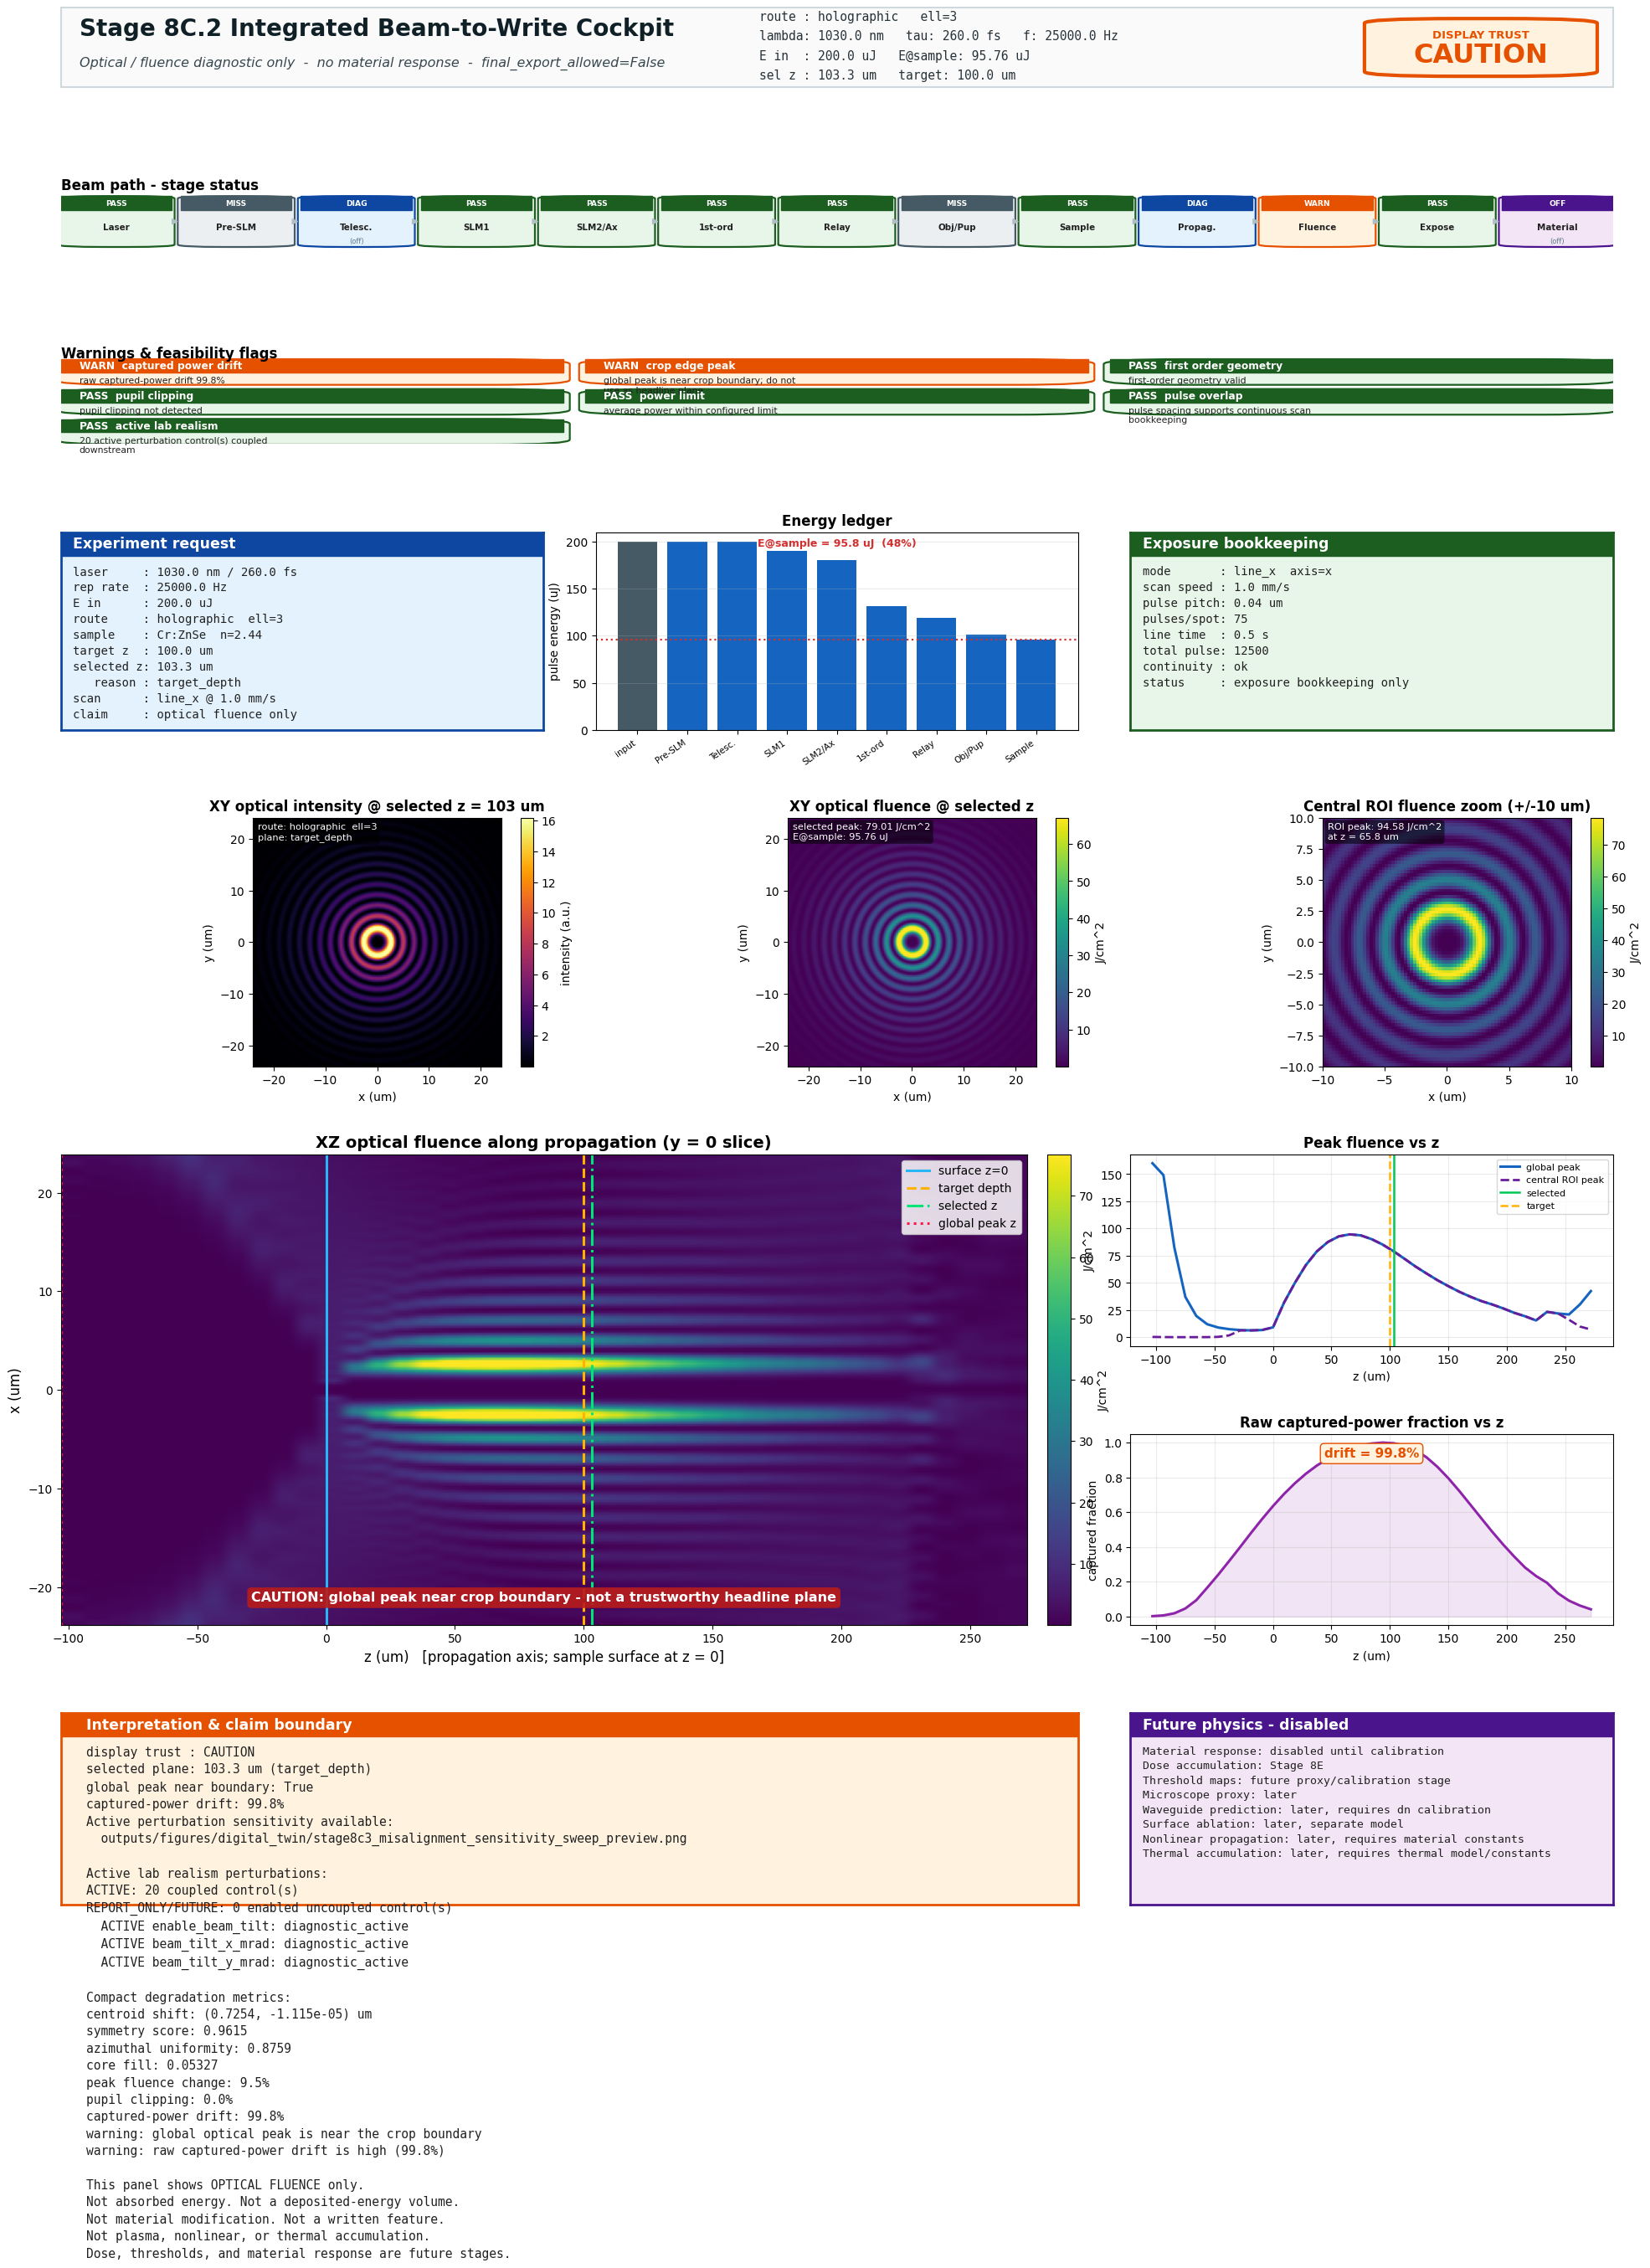

In [16]:
from IPython.display import display
import matplotlib.pyplot as plt

output_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c2_integrated_cockpit_dashboard_preview.png"
fig = plot_integrated_cockpit_dashboard(
    stack,
    fluence_stack,
    controls=controls,
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    lab_report=lab_report,
    diagnostics=diagnostics,
    output_path=output_path if save_outputs else None,
    show_caveats=show_caveats,
    dpi=figure_dpi,
    display_scaling=display_scaling,
    display_percentile_clip=display_percentile_clip,
    perturbation_result=globals().get("perturbation_result"),
    degradation_metrics=globals().get("perturbed_degradation_metrics"),
)
print("overall display-trust status:", fig.stage8c2_metadata["overall_status"])
# Render exactly one inline copy; close before cell end to avoid a duplicate auto-render.
display(fig)
plt.close(fig)
plt.show()


## 11. Interpretation panel

In [17]:
print(make_interpretation_text(
    controls=controls,
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    diagnostics=diagnostics,
    lab_report=lab_report,
))


Energy at sample is 95.76 uJ from 200.0 uJ before optics.
Average power is below the configured limit; sample average power is 2.394 W.
The optical route is valid.
The first-order geometry is valid.
Pupil fill/clipping status is not available from current engine.
Pulse spacing is 0.04 um, giving 75 pulses per spot.
For the selected plane, peak optical fluence is 79.01 J/cm^2.
Central ROI peak is 94.58 J/cm^2.
Target-depth peak is 79.01 J/cm^2.
Peak intensity estimate is 6.154e+14 W/cm^2, assuming no nonlinear reshaping.
The global field peak is near the crop boundary.
Captured-power drift is 99.80%.
Lab realism status is caution.
This output is optical fluence only; no material modification is predicted.


## 12. Disabled future physics panels

Material response: disabled until calibration

Dose accumulation: Stage 8E

Threshold maps: future proxy/calibration stage

Microscope proxy: later

Waveguide prediction: later, requires dn calibration

Surface ablation: later, separate model

Nonlinear propagation: later, requires material constants

Thermal accumulation: later, requires thermal model/constants

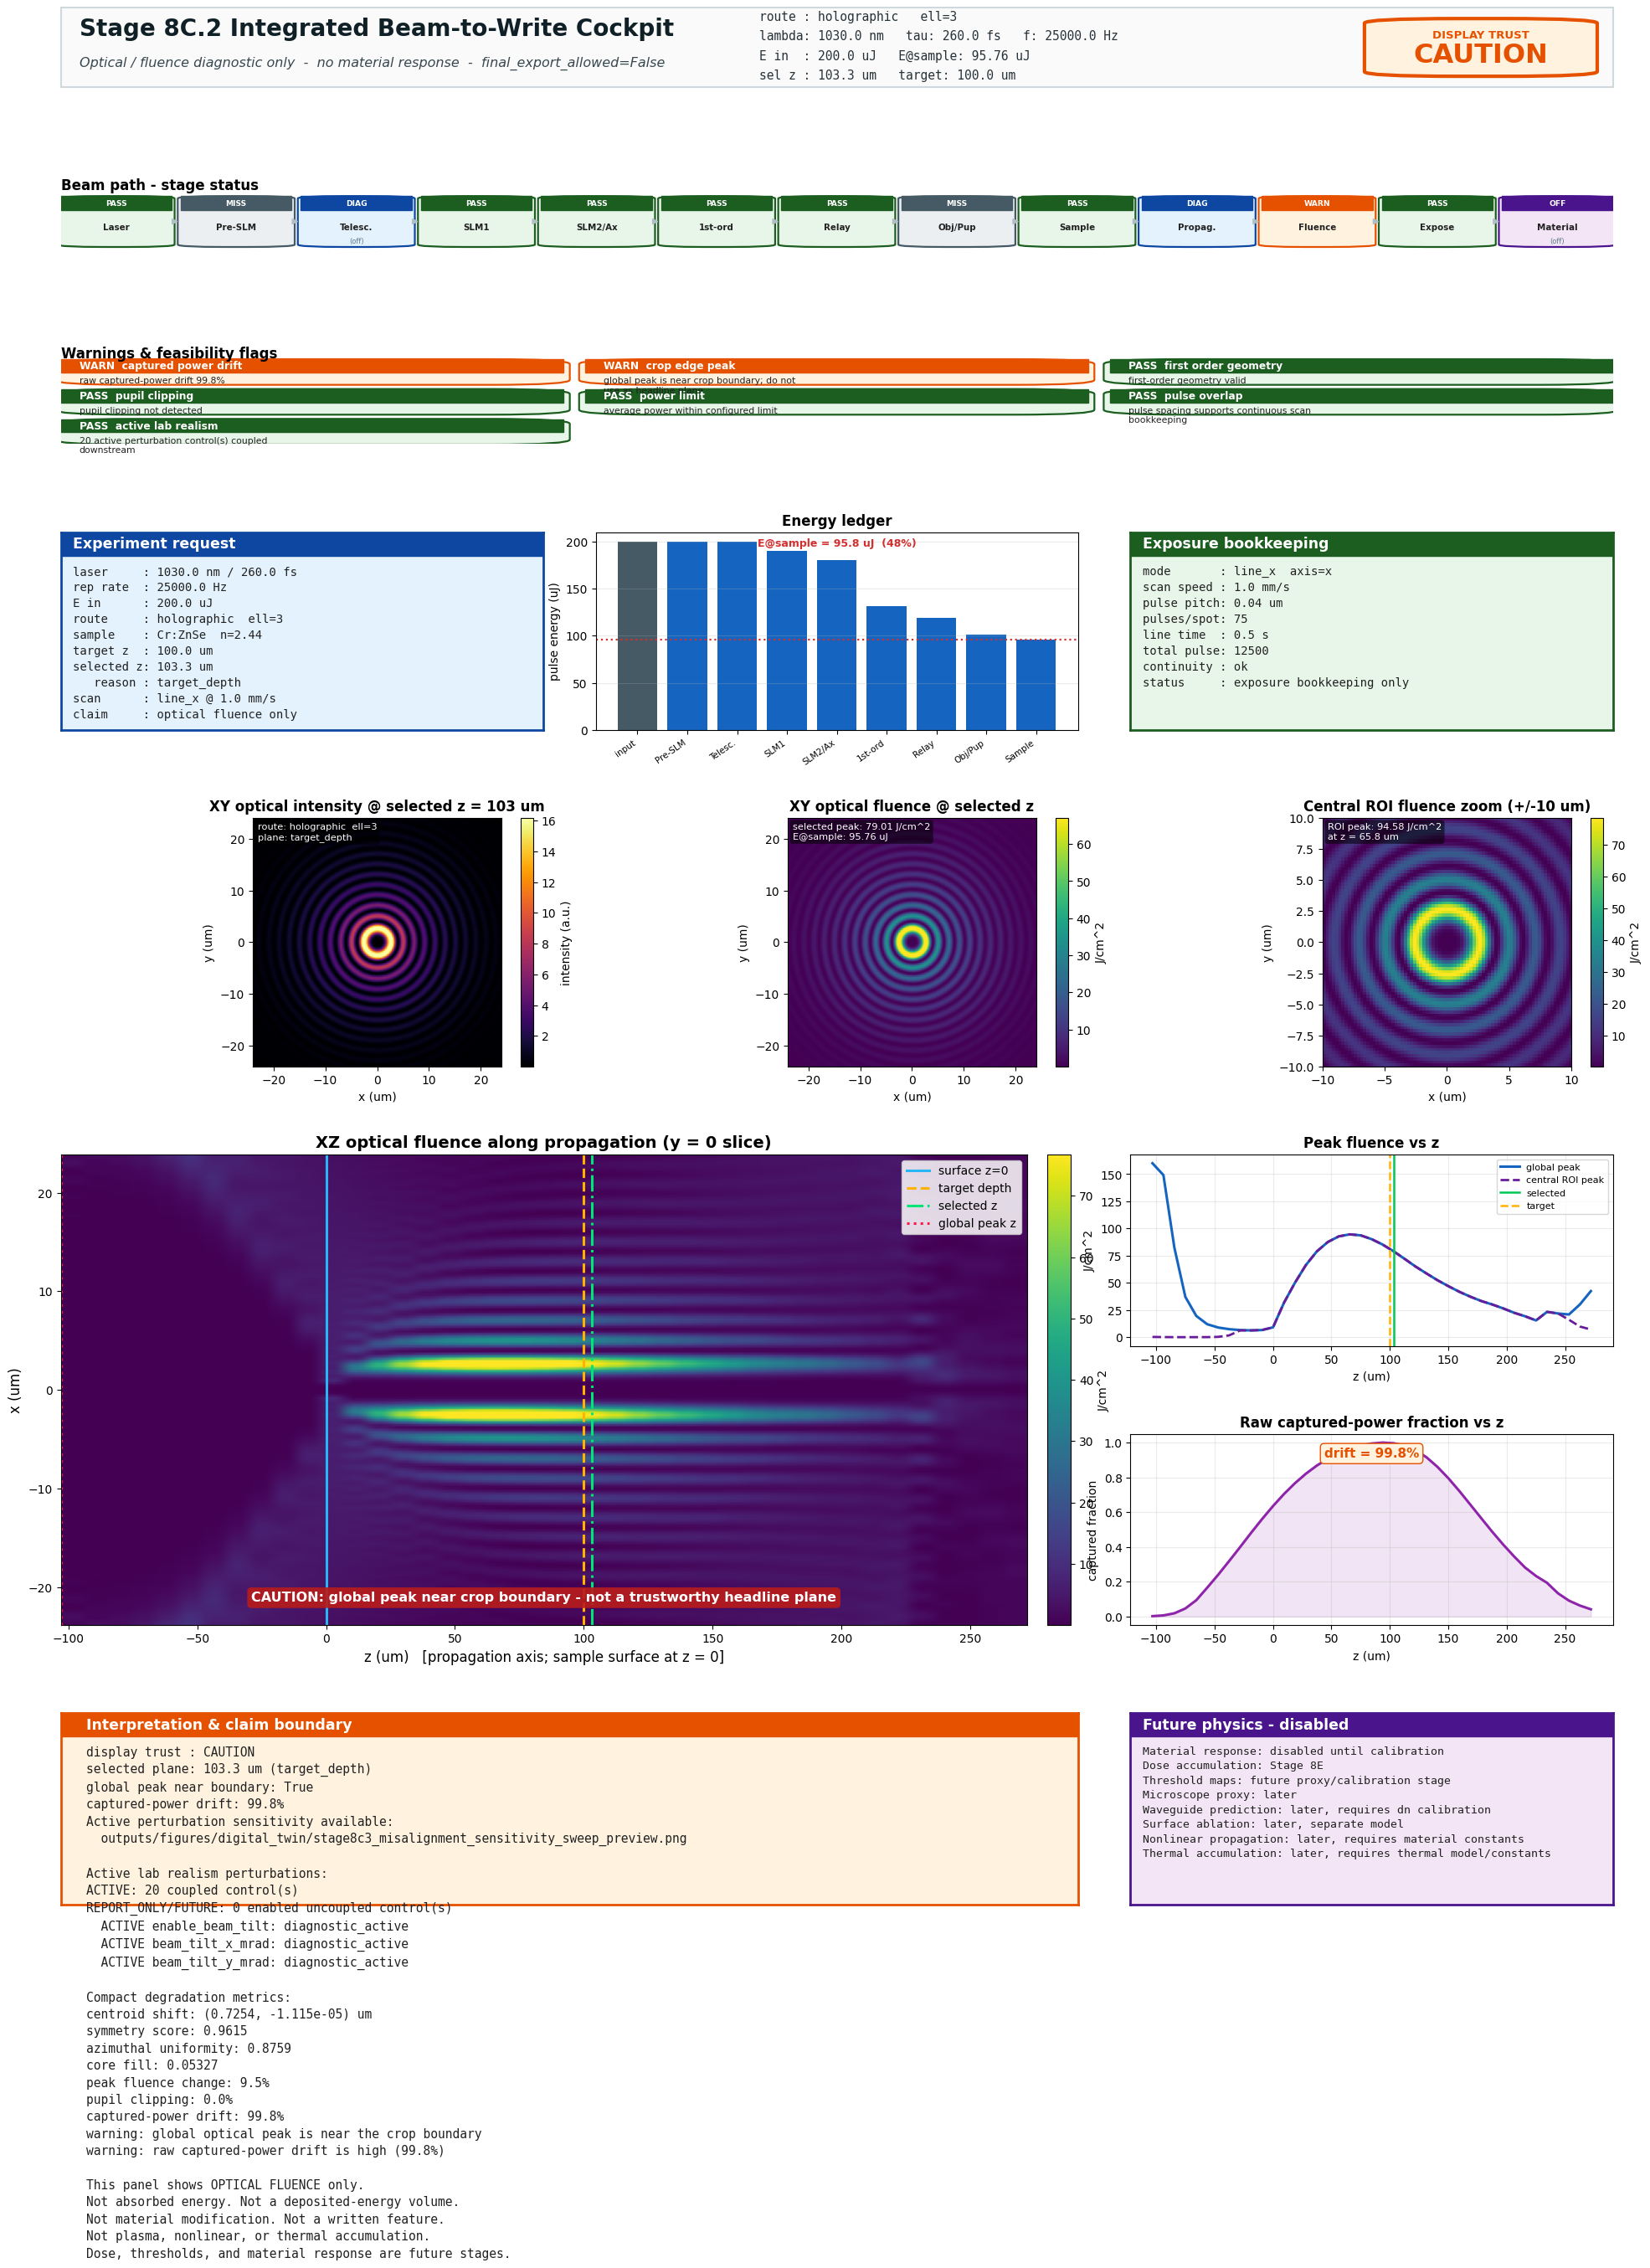

Saved diagnostic preview (final_export_allowed=False) to:
C:\PhD\Code\Publication_Study\outputs\figures\digital_twin\stage8c2_integrated_cockpit_dashboard_preview.png


In [18]:
# ============================================================
# FINAL VISUAL CHECK - confirm the dashboard rendered and save a diagnostic preview
# ============================================================
from IPython.display import display
import matplotlib.pyplot as plt

assert "fig" in globals() and fig is not None, "Cockpit dashboard figure was not created."
assert fig.stage8c2_metadata["final_export_allowed"] is False, "Dashboard must be diagnostic only."

# Show the dashboard again (single inline copy).
display(fig)
plt.show()

preview_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c2_integrated_cockpit_dashboard_preview.png"
# A diagnostic preview (final_export_allowed=False) is saved only with caveats on and only for a
# real/governed field - never for a unit_test_or_demo_only field.
if show_caveats and stack.source_status != "unit_test_or_demo_only":
    _saved = plot_integrated_cockpit_dashboard(
        stack, fluence_stack, controls=controls, energy_ledger=ledger,
        exposure_summary=exposure_summary, lab_report=lab_report, diagnostics=diagnostics,
        output_path=preview_path, show_caveats=show_caveats, dpi=figure_dpi,
        display_scaling=display_scaling, display_percentile_clip=display_percentile_clip,
        perturbation_result=globals().get("perturbation_result"),
        degradation_metrics=globals().get("perturbed_degradation_metrics"),
    )
    plt.close(_saved)
    print("Saved diagnostic preview (final_export_allowed=False) to:")
    print(preview_path)
else:
    print("Preview not saved (needs show_caveats=True and a real/governed field).")


## Stage 8C.3R.5 - Component-Owned Concatenated-SLM Baseline Route

Component-owned concatenated-SLM route scaffold for the CSLM path. This section is free-space optical diagnostics only: `n = 1.0`, `diagnostic_only`, `final_export_allowed=False`, and no material model.

SLM1 owns the vortex/topological-charge phase in this baseline. SLM2 is a correction/carrier plane and does not produce the axicon phase. The active R5 route ends at the post-SLM2 pre-4F unfiltered diagnostic plane; it is not a final lab output.

The 4F lenses, Fourier plane, and +1 order filter remain warning-only until a measured, component-owned Fourier-plane coordinate model exists.


In [ ]:
from IPython.display import display
import pandas as pd

from vbb_study.digital_twin.cslm_route import (
    CSLMRouteConfig,
    run_cslm_baseline_route,
    route_inspection_rows as cslm_route_inspection_rows,
    generate_stage8c3r5_previews,
)

# Editable Stage 8C.3R.5 controls. Values are diagnostic demo geometry unless stated otherwise.
stage8c3r5_controls = dict(
    route_mode="holographic_cslm",
    wavelength_nm=1030.0,
    input_beam_radius_um=24.0,
    slm1_phase_mode="vortex",
    slm1_topological_charge=3,
    slm1_to_slm2_distance_mm=0.040,
    slm2_conjugate_mode="preserve_vortex",
    slm2_carrier_frequency_cpm=30_000.0,
    slm2_to_pre_4f_diagnostic_distance_mm=0.120,
    order_handoff_mode="none",
    slm_phase_quantisation_levels=256,
    fourier_lens1_focal_length_mm=100.0,
    fourier_lens2_focal_length_mm=100.0,
    slm2_to_lens1_distance_mm=100.0,
    lens1_to_fourier_plane_distance_mm=100.0,
    fourier_filter_centre_x_um=0.0,
    fourier_filter_centre_y_um=0.0,
    fourier_filter_radius_um=250.0,
)

stage8c3r5_control_contract = [
    ("route_mode", "route declaration", "active", "diagnostic demo geometry"),
    ("wavelength_nm", "source/propagation", "active", "diagnostic demo geometry"),
    ("input_beam_radius_um", "source_field", "active", "diagnostic demo geometry"),
    ("slm1_phase_mode", "SLM1_phase_plane", "active", "diagnostic demo geometry"),
    ("slm1_topological_charge", "SLM1_phase_plane", "active", "diagnostic demo geometry"),
    ("slm1_to_slm2_distance_mm", "SLM1_to_SLM2_segment", "active", "diagnostic demo geometry"),
    ("slm2_conjugate_mode", "SLM2_phase_plane", "active", "diagnostic demo geometry"),
    ("slm2_carrier_frequency_cpm", "SLM2_phase_plane / 4F contract", "active carrier phase, warning-only filter", "diagnostic demo geometry"),
    ("slm2_to_pre_4f_diagnostic_distance_mm", "SLM2_to_pre_4F_diagnostic_segment", "active", "diagnostic demo geometry"),
    ("order_handoff_mode", "post-SLM2 branch selector", "none for active R5 route", "diagnostic demo geometry"),
    ("slm_phase_quantisation_levels", "SLM1 and SLM2", "active", "diagnostic demo geometry"),
    ("fourier_lens1_focal_length_mm", "Fourier_lens_1", "warning-only", "diagnostic demo geometry"),
    ("fourier_lens2_focal_length_mm", "Fourier_lens_2", "warning-only", "diagnostic demo geometry"),
    ("slm2_to_lens1_distance_mm", "SLM2_to_fourier_lens_segment", "warning-only", "diagnostic demo geometry"),
    ("lens1_to_fourier_plane_distance_mm", "Fourier_plane", "warning-only", "diagnostic demo geometry"),
    ("fourier_filter_centre_x_um", "plus_one_order_filter", "warning-only", "diagnostic demo geometry"),
    ("fourier_filter_centre_y_um", "plus_one_order_filter", "warning-only", "diagnostic demo geometry"),
    ("fourier_filter_radius_um", "plus_one_order_filter", "warning-only", "diagnostic demo geometry"),
]

display(pd.DataFrame(stage8c3r5_control_contract, columns=["control", "physical location", "status", "geometry status"]))

stage8c3r5_config = CSLMRouteConfig(**stage8c3r5_controls)
stage8c3r5_run = run_cslm_baseline_route(stage8c3r5_config)

print("executed route:", " -> ".join(stage8c3r5_run.executed_route_chain))
print("order_handoff_mode:", stage8c3r5_run.order_handoff.mode)
print("fourier_filter_physics_available:", stage8c3r5_run.fourier_filter_physics_available)
print("final_export_allowed:", stage8c3r5_run.final_export_allowed)
display(pd.DataFrame(cslm_route_inspection_rows(stage8c3r5_run)))


In [ ]:
from IPython.display import Image, display

stage8c3r5_preview_paths = generate_stage8c3r5_previews(stage8c3r5_config)
for label in ("route_inspection", "phase_and_field_baselines", "fourier_order_selection_audit"):
    print(label, stage8c3r5_preview_paths[label])
    display(Image(filename=str(stage8c3r5_preview_paths[label])))

print("phase masks", stage8c3r5_preview_paths["phase_masks"])
print("Notebook inline render path confirmed for Stage 8C.3R.5 diagnostic previews.")


## Stage 8C.3R.5.1 - CSLM-to-Physical-Axicon Handoff

This section deliberately enables the ideal selected-order benchmark branch. The actual CSLM route remains the unfiltered post-SLM2 diagnostic branch; the benchmark is carrier-free by construction and is not a physical 4F-filtered prediction.

The Bessel-forming element is the downstream physical axicon. SLM2 remains correction/carrier only and does not produce an axicon phase.


In [ ]:
from IPython.display import display
import pandas as pd

from vbb_study.digital_twin.cslm_route import (
    CSLMRouteConfig,
    run_cslm_baseline_route,
    route_inspection_rows as cslm_route_inspection_rows,
    generate_stage8c3r5_1_previews,
)

stage8c3r5_1_controls = dict(
    order_handoff_mode="ideal_selected_order_surrogate",
    slm1_topological_charge=3,
    slm2_carrier_frequency_cpm=30_000.0,
    slm2_correction_phase_rad=0.0,
    physical_axicon_enabled_for_benchmark=True,
    physical_axicon_cone_parameter_rad_per_um=1.05,
    physical_axicon_clear_aperture_radius_um=42.0,
    physical_axicon_centre_x_um=0.0,
    physical_axicon_centre_y_um=0.0,
    physical_axicon_to_benchmark_reference_distance_mm=0.120,
)

stage8c3r5_1_control_contract = [
    ("order_handoff_mode", "post-SLM2 order handoff", "benchmark-only when ideal_selected_order_surrogate", "no", "diagnostic demo geometry"),
    ("slm1_topological_charge", "SLM1_phase_plane", "active", "yes", "diagnostic demo geometry"),
    ("slm2_carrier_frequency_cpm", "SLM2_phase_plane", "active carrier / warning-only 4F contract", "yes", "diagnostic demo geometry"),
    ("slm2_correction_phase_rad", "SLM2_phase_plane", "active and benchmark surrogate", "yes", "diagnostic demo geometry"),
    ("physical_axicon_enabled_for_benchmark", "downstream physical axicon", "benchmark-only", "no", "diagnostic demo geometry"),
    ("physical_axicon_cone_parameter_rad_per_um", "physical_axicon_benchmark_plane", "benchmark-only", "no", "diagnostic demo geometry"),
    ("physical_axicon_clear_aperture_radius_um", "physical_axicon_benchmark_plane", "benchmark-only aperture loss", "no", "diagnostic demo geometry"),
    ("physical_axicon_centre_x_um", "physical_axicon_benchmark_plane", "benchmark-only", "no", "diagnostic demo geometry"),
    ("physical_axicon_centre_y_um", "physical_axicon_benchmark_plane", "benchmark-only", "no", "diagnostic demo geometry"),
    ("physical_axicon_to_benchmark_reference_distance_mm", "post_axicon_benchmark_segment", "benchmark-only", "no", "diagnostic demo geometry"),
]

display(pd.DataFrame(
    stage8c3r5_1_control_contract,
    columns=["control", "physical location", "status", "contributes to actual executed route", "geometry basis"],
))

stage8c3r5_1_config = CSLMRouteConfig(**stage8c3r5_1_controls)
stage8c3r5_1_run = run_cslm_baseline_route(stage8c3r5_1_config)

print("active CSLM route:", " -> ".join(stage8c3r5_1_run.executed_route_chain))
print("ideal benchmark route:", " -> ".join(stage8c3r5_1_run.ideal_benchmark_route_chain))
print("fourier_filter_physics_available:", stage8c3r5_1_run.fourier_filter_physics_available)
print("handoff:", stage8c3r5_1_run.order_handoff.as_dict())
print("benchmark metrics:", stage8c3r5_1_run.axicon_benchmark.metrics)
display(pd.DataFrame(cslm_route_inspection_rows(stage8c3r5_1_run)))


In [ ]:
from IPython.display import Image, display

stage8c3r5_1_preview_paths = generate_stage8c3r5_1_previews(stage8c3r5_1_config)
for label in ("handoff_audit", "unfiltered_vs_ideal_handoff", "ideal_vortex_bessel_axicon_benchmark"):
    print(label, stage8c3r5_1_preview_paths[label])
    display(Image(filename=str(stage8c3r5_1_preview_paths[label])))

print("Notebook inline render path confirmed for Stage 8C.3R.5.1 handoff benchmark previews.")


## Stage 8C.3R.5.2 — Editable Hardware and Geometry Contract

One coherent control system over the existing R5.1 config (`CSLMRouteConfig` stays the single source of model values). Each control carries a **status** (`physics_active` / `benchmark_only` / `warning_only` / `future_not_implemented` / `numerical_advanced` / `derived_read_only`) and a **provenance** (`measured` / `manufacturer_specification` / `estimated` / `diagnostic_placeholder` / `unknown` / `derived`).

**Changing `SLM1 topological charge`, `SLM2 carrier frequency`, the `SLM2 uniform piston placeholder`, active propagation distances, `order_handoff_mode`, or the physical-axicon benchmark settings changes active/benchmark calculations.** **Changing `4F lens distances`, `Fourier stop geometry`, `camera settings`, `SLM pixel pitch / fill factor / active area` does NOT change the current field** — component-owned physical 4F propagation is not implemented, so those are editable hardware records only. `diagnostic_only` and `final_export_allowed` are locked governance values. Boundary unchanged: `n=1.0` free-space; `fourier_filter_physics_available=False`; no material/4F/camera physics.

In [ ]:
from vbb_study.digital_twin.control_contract import (
    build_cslm_editable_control_registry, editable_control_rows, apply_editable_control_overrides,
    build_default_demo_profile, build_measured_bench_template, validate_hardware_profile,
    hardware_profile_completeness_report, save_hardware_profile, load_hardware_profile,
    config_from_profile, status_counts, plot_hardware_profile_completeness,
)
from vbb_study.digital_twin.cslm_route import CSLMRouteConfig
import pandas as pd
from IPython.display import display

# 1. profile selector / load
hardware_profile_path = 'configs/hardware/cslm_physical_axicon_demo_profile.json'
r52_profile = load_hardware_profile(hardware_profile_path)
print('Loaded profile:', r52_profile['profile_name'], '| status:', r52_profile['profile_status'])
print('profile valid (no issues):', validate_hardware_profile(r52_profile) == [])

# 2. EDIT THESE basic experiment controls, then re-run (active/benchmark calculations).
r52_basic_overrides = {
    # 'slm1_topological_charge': 3,
    # 'slm2_carrier_frequency_cpm': 30000.0,
    # 'slm2_correction_phase_rad': 0.0,          # uniform piston placeholder (NOT a correction map)
    # 'order_handoff_mode': 'none',              # 'ideal_selected_order_surrogate' enables benchmark
}
r52_config = config_from_profile(r52_profile, CSLMRouteConfig())
r52_config = apply_editable_control_overrides(r52_config, r52_basic_overrides)
r52_registry = build_cslm_editable_control_registry(r52_config, profile=r52_profile)
r52_df = pd.DataFrame(editable_control_rows(r52_registry))

# 3. active vs benchmark-only vs warning-only control tables
print('--- physics_active (affect the active CSLM field) ---'); display(r52_df[r52_df.status=='physics_active'])
print('--- benchmark_only (affect the opt-in ideal axicon benchmark) ---'); display(r52_df[r52_df.status=='benchmark_only'])
print('--- warning_only (editable hardware records; NO active effect yet) ---'); display(r52_df[r52_df.status=='warning_only'])

# 4. advanced numerical controls (not laboratory hardware)
print('--- numerical_advanced (not laboratory hardware) ---'); display(r52_df[r52_df.status=='numerical_advanced'])

# 5. hardware-profile completeness report
r52_report = hardware_profile_completeness_report(r52_profile, config=r52_config)
print('Readiness:', {k: r52_report[k] for k in ['active_cslm_diagnostic_branch','ideal_axicon_benchmark_branch','physical_4f_route','measured_lab_route','camera_comparison']})

# 6. route-status summary
print('Control status counts:', status_counts(r52_registry))

# 7. what changes figures vs future-only
print('AFFECTS ACTIVE/BENCHMARK FIGURES: SLM1 charge/mode/ramp, SLM1->SLM2 distance, SLM2 carrier,')
print('  SLM2 piston placeholder, quantisation, order_handoff_mode, numerical grid; physical axicon (benchmark).')
print('RECORDED FOR FUTURE PHYSICS ONLY (no field change): 4F lens distances/apertures, Fourier stop,')
print('  camera settings, SLM pixel pitch / fill factor / active area.')

# 8. save / export profile (uncomment to write)
# save_hardware_profile(build_default_demo_profile(r52_config), 'configs/hardware/cslm_physical_axicon_demo_profile.json')

# 9. completeness figure (inline + saved)
r52_fig = plot_hardware_profile_completeness(r52_profile, config=r52_config,
    output_path='outputs/figures/digital_twin/stage8c3r5_2_hardware_profile_completeness.png')
display(r52_fig); plt.close(r52_fig)

print('Changing these values does not yet change the active optical field because component-owned')
print('physical 4F propagation is not implemented.  diagnostic_only; final_export_allowed = False; n = 1.0.')


## Stage 8C.3R.5.3 — Bench Inventory, Coordinates, and 4F Readiness Gate

Turns the R5.2 controls into a disciplined bench record + coordinate-convention contract + a four-level physical-4F readiness gate. **No physical 4F field is generated in this notebook section. Changing 4F inventory values updates readiness only, not the active optical field.** Coordinate mapping (SLM2 pixel → lab x/y, Fourier-plane spatial-frequency → physical mm) is *mandatory* for carrier-order positioning and later camera comparison, and is currently **unknown** — which is exactly why levels C and D are blocked. Boundary unchanged: `n=1.0` free-space; `fourier_filter_physics_available=False`; no material/camera physics; `final_export_allowed=False`.

In [ ]:
from vbb_study.digital_twin.bench_inventory import (
    build_bench_inventory, bench_inventory_rows, build_bench_inventory_profile,
    save_bench_inventory, load_bench_inventory, evaluate_physical_4f_readiness,
    readiness_summary_rows, measurement_checklist, plot_physical_4f_readiness_gate,
)
from vbb_study.digital_twin.coordinate_contract import (
    build_coordinate_frames, build_coordinate_transforms,
    coordinate_frame_rows, coordinate_transform_rows, validate_coordinate_contract,
)
from vbb_study.digital_twin.control_contract import load_hardware_profile
import pandas as pd
from IPython.display import display

# 1. selected hardware profile + provenance
r53_inventory_path = 'configs/hardware/cslm_physical_axicon_bench_inventory.json'
r53_inventory_profile = load_bench_inventory(r53_inventory_path)
print('Inventory profile:', r53_inventory_profile['profile_name'], '| status:', r53_inventory_profile['profile_status'])
r53_overlay = r53_inventory_profile.get('items', {})

# 2. editable bench-inventory table (edit the JSON to add measured values + evidence)
r53_inv_df = pd.DataFrame(bench_inventory_rows(build_bench_inventory(inventory_overlay=r53_overlay)))
print('--- bench inventory (req_4F = hard blocker for initial scalar 4F model) ---')
display(r53_inv_df)

# 3. coordinate-frame declarations
print('--- coordinate frames (unknown calibration blocks measured-bench readiness) ---')
display(pd.DataFrame(coordinate_frame_rows()))

# 4. coordinate-transform declarations
print('--- coordinate transforms (modelled vs calibration_required) ---')
display(pd.DataFrame(coordinate_transform_rows()))
print('coordinate contract valid:', validate_coordinate_contract() == [])

# 5. readiness summary A-D
r53_readiness = evaluate_physical_4f_readiness(inventory_overlay=r53_overlay)
print('--- readiness levels A-D ---')
display(pd.DataFrame(readiness_summary_rows(r53_readiness)))

# 6. hard blockers for physical 4F (level C)
print('Physical-4F hard blockers (level C):')
for b in r53_readiness['C_initial_scalar_4f_model']['blocked_by']:
    print('  -', b)

# 7. prioritised measurement checklist
print('Prioritised measurement checklist:')
display(pd.DataFrame(measurement_checklist(r53_readiness)))

# 8. export updated inventory / profile (uncomment to write)
# save_bench_inventory(build_bench_inventory_profile(), r53_inventory_path)

# readiness figure (inline + saved)
r53_fig = plot_physical_4f_readiness_gate(inventory_overlay=r53_overlay,
    output_path='outputs/figures/digital_twin/stage8c3r5_3_physical_4f_readiness_gate.png')
display(r53_fig); plt.close(r53_fig)

# 9. explicit boundary statement
print('No physical 4F field is generated in this notebook section.')
print('Changing 4F inventory values updates readiness only, not the active optical field.')
print('fourier_filter_physics_available =', r53_readiness['fourier_filter_physics_available'],
      '| final_export_allowed =', r53_readiness['final_export_allowed'], '| n = 1.0 free-space.')


## Stage 9A — Calibration Acquisition and Measured-Data Ingestion

Structured acquisition, storage, ingestion, and pixel-space analysis tooling for a real optical calibration campaign of the CSLM → 4F → physical-axicon route. **No physical 4F field, camera-imaging model, inverse correction, neural network, or material-response model is active in this section.** Raw camera files are immutable source evidence (checksummed, not committed by default). Pixel metrics are valid before calibration; physical-unit (µm/mm) metrics are blocked until a declared camera scale + named reference-plane relation exist. Boundary: `n=1.0` free-space; `fourier_filter_physics_available=False`; `camera_model_enabled=False`; `material_model_enabled=False`; `final_export_allowed=False`. The demo below uses a clearly-labelled **synthetic** image (not laboratory data) written to a scratch directory.

In [ ]:
import tempfile, numpy as np
from pathlib import Path
from vbb_study.digital_twin.calibration_acquisition import (
    build_calibration_campaign_v1, create_calibration_acquisition_package, generate_run_id,
    ingest_calibration_capture, validate_capture_manifest, write_capture_manifest,
    plot_calibration_campaign_overview,
)
from vbb_study.digital_twin.measured_image_metrics import (
    compute_measured_image_metrics, image_quality_report, compare_measured_to_model,
)
from vbb_study.digital_twin.cslm_route import CSLMRouteConfig
import pandas as pd
from IPython.display import display

# 1. calibration campaign overview
s9a_campaign = build_calibration_campaign_v1()
print('Campaign:', s9a_campaign['campaign_name'], '| status:', s9a_campaign['campaign_status'])
display(pd.DataFrame([{'family': f"F{f['family_id']}", 'name': f['name'],
                       'captures': len(f['captures']), 'plane': f.get('coordinate_frame',''),
                       'identifies': f.get('identifies','')} for f in s9a_campaign['families']]))

# 2. editable run descriptor + route/profile selection
s9a_config = CSLMRouteConfig()                      # edit route/profile values via the R5.2 contract
s9a_run_id = generate_run_id('demo')
s9a_scratch = Path(tempfile.mkdtemp(prefix='stage9a_demo_'))  # scratch; not the real data dir

# 3. acquisition-package generation
s9a_paths = create_calibration_acquisition_package(
    s9a_run_id, config=s9a_config,
    output_root=s9a_scratch/'outputs', data_root=s9a_scratch/'data')
print('Run package:', s9a_run_id)
print('  files:', sorted(p.name for p in s9a_paths['run_dir'].iterdir()))
print('  experiment templates:', sorted(p.name for p in s9a_paths['experiment_package_dir'].iterdir()))

# 4. visible capture-plan table
s9a_plan = pd.read_csv(s9a_paths['acquisition_plan'])
display(s9a_plan.head(20))

# 5. bench inventory / readiness snapshot
import json as _json
s9a_readiness = _json.load(open(s9a_paths['run_manifest']))['physical_4f_readiness_levels']
print('Physical-4F readiness snapshot:', s9a_readiness)

# 6. raw-data ingestion (SYNTHETIC demo image; not laboratory data)
N = 96; yy, xx = np.mgrid[0:N, 0:N]; rr = np.hypot(xx-48, yy-46)
s9a_demo_image = (220.0*np.exp(-((rr-14)**2)/(2*3.5**2))).astype(np.uint16)  # synthetic annulus
s9a_src = s9a_scratch/'synthetic_unit_test_only_F5_l3_z05.npy'; np.save(s9a_src, s9a_demo_image)
s9a_capture = ingest_calibration_capture(
    s9a_paths['data_dir'], s9a_src, capture_id='F5_l3_z05', capture_kind='post_axicon_z_stack',
    run_id=s9a_run_id, topological_charge=3, notes='synthetic_unit_test_only; not_laboratory_data')
print('Ingested:', s9a_capture.capture_id, '| sha256[:16]:', s9a_capture.raw_file_sha256[:16],
      '| status:', s9a_capture.capture_status)

# 7. capture-manifest validation
s9a_manifest_path = write_capture_manifest(s9a_paths['run_dir'], [s9a_capture])
s9a_manifest = pd.read_csv(s9a_manifest_path).fillna('')
print('Capture manifest issues:', validate_capture_manifest(s9a_manifest.to_dict('records')))

# 8-9. measured-image quality + metric tables
s9a_metrics = compute_measured_image_metrics(s9a_demo_image.astype(float), bit_depth=16)
s9a_quality = image_quality_report(s9a_demo_image.astype(float), bit_depth=16, expect_annular=True)
display(pd.DataFrame([{'metric': k, 'value': v} for k, v in s9a_metrics.items()
                      if k not in ('radial_profile_px', 'image_quality_flags')]))
print('Quality:', s9a_quality['quality_status'], '| flags:', s9a_quality['flags'],
      '| metric_validity:', s9a_quality['metric_validity'])

# 10. explicit comparison-boundary table
s9a_cmp = compare_measured_to_model(s9a_metrics, {'ring_radius_um': 4.0})
print('Comparison status (uncalibrated):', s9a_cmp['comparison_status'])
print('  shape-only label:', s9a_cmp['shape_only_diagnostic_comparison']['label'])

# 11. visualisation: ingested image + ring-centre/centroid overlay (pixels)
fig9a, ax9a = plt.subplots(1, 2, figsize=(11, 4.6))
im = ax9a[0].imshow(s9a_demo_image, origin='lower', cmap='viridis')
ax9a[0].plot(s9a_metrics['intensity_centroid_x_px'], s9a_metrics['intensity_centroid_y_px'],
             '+', color='white', ms=12, mew=2, label='centroid (px)')
ax9a[0].plot(s9a_metrics['ring_centre_x_px'], s9a_metrics['ring_centre_y_px'],
             'x', color='red', ms=10, mew=2, label='ring centre (px)')
ax9a[0].set_title('synthetic ingested image (pixels)\nnot_laboratory_data'); ax9a[0].legend(fontsize=8)
ax9a[0].set_xlabel('x (px)'); ax9a[0].set_ylabel('y (px)'); fig9a.colorbar(im, ax=ax9a[0], fraction=0.046)
ax9a[1].plot(s9a_metrics['radial_profile_px']); ax9a[1].set_title('radial profile (pixels)')
ax9a[1].set_xlabel('radius (px-bin)'); ax9a[1].set_ylabel('mean intensity'); ax9a[1].grid(alpha=0.3)
fig9a.tight_layout(); display(fig9a); plt.close(fig9a)

# campaign overview figure (inline + saved)
fig9a_ov = plot_calibration_campaign_overview(s9a_campaign, config=s9a_config,
    output_path='outputs/figures/digital_twin/stage9a_calibration_campaign_overview.png')
display(fig9a_ov); plt.close(fig9a_ov)

# 12. explicit boundary statement
print('No physical 4F field, camera-imaging model, inverse correction, neural network,')
print('or material-response model is active in this section.')
print('fourier_filter_physics_available = False | camera_model_enabled = False |',
      'material_model_enabled = False | final_export_allowed = False | n = 1.0 free-space.')


## Stage 9A.1 — First Fourier-Plane Carrier Calibration Session

Generates the exact SLM masks, capture plan, manifests, and lab setup sheet for the first physical CSLM → 4F session: **SLM1 = flat**, **SLM2 = command-domain carrier ramp only**, **physical axicon removed/bypassed**, camera at the Fourier plane (or accessible equivalent).

> **Carrier values are command-domain cycles across the displayed SLM area. They are not physical spatial-frequency values until SLM geometry and Fourier-plane calibration are recorded.**

No vortex / axicon / correction map / inverse optimisation. No physical 4F propagation, camera physics, or material model. `physical_4f_filter_modelled=False`; `camera_model_enabled=False`; `material_model_enabled=False`; `final_export_allowed=False`. The demo writes to a scratch directory.

In [ ]:
import tempfile
from pathlib import Path
from vbb_study.digital_twin.slm_calibration_masks import (
    CarrierSweepConfig, build_carrier_sweep_masks, build_carrier_calibration_study,
    create_fourier_carrier_calibration_session, plot_command_domain_carrier_mask_atlas,
)
import pandas as pd
from IPython.display import display

# --- EDITABLE first-session controls (command domain; not physical frequency) ---
s9a1_carrier = CarrierSweepConfig(
    command_display_width_pixels=480,          # display resolution source (placeholder; record real SLM)
    command_display_height_pixels=300,
    command_display_resolution_source='demo_placeholder_not_measured',
    command_axes=('x', 'y'),                   # SLM2 carrier axes
    carrier_cycles=(-24, -16, -8, 0, 8, 16, 24),  # signed command cycles across display
    optional_diagonal_cases=((8, 8), (8, -8), (-8, 8), (-8, -8)),
    phase_quantisation_levels=256,
    minimum_pixels_per_carrier_cycle=8,        # sampling guard (no aliasing)
    dark_frame_repeats=5, flat_reference_repeats=3, capture_repeats=1,
    camera_plane_label='fourier_plane_or_accessible_equivalent',
    fourier_stop_state='record_actual_state_do_not_assume',
    physical_axicon_state='removed_or_bypassed_not_in_active_path',
)
s9a1_outdir = Path(tempfile.mkdtemp(prefix='stage9a1_demo_'))   # scratch; not the real data dir

# --- create the first-session package -----------------------------------------
s9a1_paths = create_fourier_carrier_calibration_session(
    carrier_config=s9a1_carrier,
    output_root=s9a1_outdir/'outputs', data_root=s9a1_outdir/'data',
    save_atlas_to='outputs/figures/digital_twin/stage9a1_command_domain_carrier_mask_atlas.png')
print('Session run dir:', s9a1_paths['run_dir'])
print('  package files:', sorted(p.name for p in s9a1_paths['run_dir'].iterdir()))
print('  SLM2 masks exported:', len(list(s9a1_paths['phase_masks_slm2_dir'].glob('*_metadata.json'))))
print('  LAB README:', (s9a1_paths['experiment_package_dir']/'LAB_README_FIRST_FOURIER_SESSION.md').name)

# --- capture plan table -------------------------------------------------------
s9a1_plan = pd.read_csv(s9a1_paths['acquisition_plan']).fillna('')
display(s9a1_plan[['capture_id','slm1_mask_id','slm2_mask_id','carrier_cycles_x','carrier_cycles_y',
                   'command_axis','purpose','capture_status','raw_target_path']])

print('Carrier values are command-domain cycles across the displayed SLM area.')
print('They are not physical spatial-frequency values until SLM geometry and')
print('Fourier-plane calibration are recorded.')

# --- mask atlas (inline) ------------------------------------------------------
s9a1_masks = build_carrier_sweep_masks(s9a1_carrier)
s9a1_fig = plot_command_domain_carrier_mask_atlas(s9a1_masks, s9a1_carrier)
display(s9a1_fig); plt.close(s9a1_fig)

print('No physical 4F field, camera model, inverse correction, neural network,')
print('physical-axicon propagation, or material model is active in this section.')
print('physical_4f_filter_modelled = False | camera_model_enabled = False |',
      'material_model_enabled = False | final_export_allowed = False.')


## Stage 9A.1B - Downstream-Focus Carrier and Stop Characterisation

Dual-mode calibration contract: `direct_fourier_plane_access` is retained for temporary Fourier-plane or conjugate-plane diagnostics; `downstream_focus_empirical` is the current installed-camera default.

**Warning:** With the installed downstream camera, this experiment characterises the final response to carrier and stop settings. It does not directly measure Fourier-plane order positions or by itself calibrate the physical 4F coordinate system.

Boundary: no physical 4F propagation, no camera model, no inverse correction, no AI, no material response, `final_export_allowed=False`.


In [ ]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

from vbb_study.digital_twin.downstream_carrier_stop import (
    AXICON_STATE_CHOICES,
    CAPTURE_FAMILIES,
    DOWNSTREAM_CAMERA_WARNING,
    DownstreamCarrierStopConfig,
    build_calibration_access_modes,
    build_downstream_carrier_stop_study,
    create_downstream_carrier_stop_characterisation_session,
    downstream_capture_plan_rows,
    plot_downstream_carrier_stop_session_overview,
)

# Editable Stage 9A.1B controls
stage9a1b_calibration_mode = "downstream_focus_empirical"
stage9a1b_carrier_cycles = (-24, -16, -8, 0, 8, 16, 24)
stage9a1b_fixed_stop_centre_x = "baseline_recorded"
stage9a1b_fixed_stop_centre_y = "baseline_recorded"
stage9a1b_fixed_stop_radius_or_aperture_label = "baseline_recorded"
stage9a1b_stop_centre_sweep_offsets = ("negative_small", "baseline", "positive_small")
stage9a1b_stop_radius_or_aperture_sweep_labels = ("smaller", "baseline", "larger")
stage9a1b_camera_plane_label = "downstream_final_focus"
stage9a1b_physical_axicon_state = "recorded_and_user_editable"
stage9a1b_default_axicon_recorded_state = "unknown_recorded"
stage9a1b_downstream_optics_state = "recorded_fixed_existing_route"
stage9a1b_generate_session_package = False
stage9a1b_run_id = None

stage9a1b_config = DownstreamCarrierStopConfig(
    calibration_mode=stage9a1b_calibration_mode,
    carrier_cycles=tuple(stage9a1b_carrier_cycles),
    fixed_stop_centre_x=stage9a1b_fixed_stop_centre_x,
    fixed_stop_centre_y=stage9a1b_fixed_stop_centre_y,
    fixed_stop_radius_or_aperture_label=stage9a1b_fixed_stop_radius_or_aperture_label,
    stop_centre_sweep_offsets=tuple(stage9a1b_stop_centre_sweep_offsets),
    stop_radius_or_aperture_sweep_labels=tuple(stage9a1b_stop_radius_or_aperture_sweep_labels),
    camera_plane_label=stage9a1b_camera_plane_label,
    physical_axicon_state=stage9a1b_physical_axicon_state,
    default_physical_axicon_recorded_state=stage9a1b_default_axicon_recorded_state,
    downstream_optics_state=stage9a1b_downstream_optics_state,
)

stage9a1b_modes = build_calibration_access_modes()
stage9a1b_study = build_downstream_carrier_stop_study(stage9a1b_config)
stage9a1b_capture_plan = downstream_capture_plan_rows(stage9a1b_config)

print(DOWNSTREAM_CAMERA_WARNING)
display(pd.DataFrame(stage9a1b_modes.values())[[
    "mode_id", "measurement_plane_label", "camera_access_status", "physical_4f_readiness_effect"
]])
display(pd.DataFrame(stage9a1b_capture_plan).head(20))
display(pd.DataFrame([
    {"boundary": "empirical_downstream_operating_point", "status": "allowed downstream summary"},
    {"boundary": "not_direct_fourier_plane_calibration", "status": "must remain labelled"},
    {"boundary": "not_physical_4f_model_validation", "status": "must remain labelled"},
    {"boundary": "allowed axicon states", "status": ", ".join(AXICON_STATE_CHOICES)},
    {"boundary": "capture families", "status": ", ".join(CAPTURE_FAMILIES)},
]))

stage9a1b_overview_path = Path("outputs/figures/digital_twin/stage9a1b_downstream_carrier_stop_session_overview.png")
if not stage9a1b_overview_path.exists():
    fig = plot_downstream_carrier_stop_session_overview(stage9a1b_config, output_path=stage9a1b_overview_path)
else:
    fig = None
display(Image(filename=str(stage9a1b_overview_path)))

if stage9a1b_generate_session_package:
    stage9a1b_paths = create_downstream_carrier_stop_characterisation_session(
        stage9a1b_run_id,
        config=stage9a1b_config,
        output_root="outputs/calibration_runs",
        data_root="data/calibration_runs",
        save_overview_to=stage9a1b_overview_path,
    )
    display(pd.DataFrame([{"artifact": k, "path": str(v)} for k, v in stage9a1b_paths.items()]))


## Stage 9A.2 ? Evidence, Research Gaps, and Claim Boundaries

Code-to-evidence audit only. This section does not activate physical 4F propagation, camera imaging, inverse correction, neural networks, or material response. It displays compact tables from the Stage 9A.2 registers so the live notebook keeps claim boundaries, bench blockers, manufacturer blockers, literature blockers, and legacy branch exclusions visible before the first lab session.


In [ ]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

stage9a2_root = Path('.')
stage9a2_registry = json.loads((stage9a2_root/'configs/evidence/project_claim_registry.json').read_text(encoding='utf-8'))
stage9a2_backlog = json.loads((stage9a2_root/'configs/evidence/research_backlog.json').read_text(encoding='utf-8'))
stage9a2_manufacturer = json.loads((stage9a2_root/'configs/evidence/manufacturer_evidence_register.json').read_text(encoding='utf-8'))
stage9a2_bench = json.loads((stage9a2_root/'configs/evidence/bench_evidence_register.json').read_text(encoding='utf-8'))
stage9a2_search = json.loads((stage9a2_root/'configs/evidence/literature_search_plan.json').read_text(encoding='utf-8'))

active_components = pd.DataFrame({'active route components': stage9a2_registry['active_route_components']})
display(active_components)

claims = pd.DataFrame(stage9a2_registry['claims'])
claim_table = claims[['claim_id', 'current_status', 'evidence_status', 'publication_claim_readiness']].copy()
claim_table['next_action'] = claims.apply(lambda r: (r['bench_evidence_required'] or r['manufacturer_evidence_required'] or r['literature_reference_keys'] or ['none'])[0], axis=1)
display(claim_table)

bench_blockers = pd.DataFrame(stage9a2_bench['entries'])[['evidence_id', 'measurement', 'current_value_state', 'ready']]
manufacturer_blockers = pd.DataFrame(stage9a2_manufacturer['entries'])[['evidence_id', 'component', 'current_value_state', 'verified']]
literature_blockers = pd.DataFrame(stage9a2_search['entries'])[['claim_id', 'candidate_source_status', 'research_question']]
print('Bench blockers')
display(bench_blockers)
print('Manufacturer-specification blockers')
display(manufacturer_blockers)
print('Literature/source blockers')
display(literature_blockers)

backlog = pd.DataFrame(stage9a2_backlog['items'])
display(backlog.sort_values(['priority', 'research_id'])[['research_id', 'priority', 'time_horizon', 'title', 'status']])

legacy = pd.DataFrame(stage9a2_registry['code_inventory'])
legacy = legacy[legacy['classification'].isin(['legacy_retained', 'experimental_development', 'deprecated_do_not_extend'])]
display(legacy[['item_id', 'classification', 'path', 'current_route_or_study_relevance']])

correction = claims[claims['claim_id'].isin([
    'multi_plane_phase_retrieval_future',
    'effective_aberration_inference_future',
    'zernike_or_phase_conjugate_correction_future',
    'neural_fast_estimator_future',
])][['claim_id', 'current_status', 'physics_status', 'evidence_status']]
print('Future correction roadmap')
display(correction)

print('Legacy material warning: CrZnSe proxy branches are retained but excluded from fused-silica TGV, waveguide, welding, or modification decisions.')
print('fourier_filter_physics_available=False | camera_model_enabled=False | material_model_enabled=False | final_export_allowed=False')


In [ ]:
stage9a2_figure = Path('outputs/figures/digital_twin/stage9a2_code_to_evidence_roadmap.png')
print(stage9a2_figure)
display(Image(filename=str(stage9a2_figure)))
print('Notebook JSON includes Stage 9A.2 evidence section; full references are not embedded here.')


## Stage 9A.3 - Verified Methods Evidence and Open Validation Layers

Verified bibliography keys are now linked to claim IDs, while manufacturer and bench validation remain separate evidence layers. No physical 4F, camera model, correction engine, AI, or material response is enabled.


In [ ]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display

registry = json.loads(Path('configs/evidence/project_claim_registry.json').read_text())
claims = registry['claims']
rows = []
for claim in claims:
    rows.append({
        'claim ID': claim['claim_id'],
        'implemented status': claim['current_status'],
        'verified literature key(s)': ', '.join(claim.get('verified_literature_keys', [])) or 'none',
        'manufacturer evidence status': claim.get('manufacturer_specification_status', 'not_recorded'),
        'bench evidence status': claim.get('bench_evidence_status', 'not_recorded'),
        'what can currently be claimed': claim.get('what_can_currently_be_claimed', ''),
        'what cannot currently be claimed': claim.get('what_cannot_currently_be_claimed', ''),
        'next action': claim.get('next_action', ''),
    })
evidence_df = pd.DataFrame(rows)
display(evidence_df)

fused_ids = [
    'fused_silica_bessel_channel_or_tgv_future',
    'fused_silica_waveguide_future',
    'fused_silica_welding_future',
]
display(evidence_df[evidence_df['claim ID'].isin(fused_ids)])
print('Stage 9A.3 boundary: literature principle support is not bench validation or material-process validation.')
